# Achitecture Codes

In [ ]:
#SRVGG Achitecture
from basicsr.utils.registry import ARCH_REGISTRY
from torch import nn as nn
from torch.nn import functional as F
#Discriminator
from basicsr.utils.registry import ARCH_REGISTRY
from torch import nn as nn
from torch.nn import functional as F
from torch.nn.utils import spectral_norm
#Initiation
import importlib
from basicsr.utils import scandir
from os import path as osp

# automatically scan and import arch modules for registry
# scan all the files that end with '_arch.py' under the archs folder
arch_folder = osp.dirname(osp.abspath(__file__))
arch_filenames = [osp.splitext(osp.basename(v))[0] for v in scandir(arch_folder) if v.endswith('_arch.py')]
# import all the arch modules
_arch_modules = [importlib.import_module(f'realesrgan.archs.{file_name}') for file_name in arch_filenames]


@ARCH_REGISTRY.register()
class UNetDiscriminatorSN(nn.Module):
    """Defines a U-Net discriminator with spectral normalization (SN)

    It is used in Real-ESRGAN: Training Real-World Blind Super-Resolution with Pure Synthetic Data.

    Arg:
        num_in_ch (int): Channel number of inputs. Default: 3.
        num_feat (int): Channel number of base intermediate features. Default: 64.
        skip_connection (bool): Whether to use skip connections between U-Net. Default: True.
    """

    def __init__(self, num_in_ch, num_feat=64, skip_connection=True):
        super(UNetDiscriminatorSN, self).__init__()
        self.skip_connection = skip_connection
        norm = spectral_norm
        # the first convolution
        self.conv0 = nn.Conv2d(num_in_ch, num_feat, kernel_size=3, stride=1, padding=1)
        # downsample
        self.conv1 = norm(nn.Conv2d(num_feat, num_feat * 2, 4, 2, 1, bias=False))
        self.conv2 = norm(nn.Conv2d(num_feat * 2, num_feat * 4, 4, 2, 1, bias=False))
        self.conv3 = norm(nn.Conv2d(num_feat * 4, num_feat * 8, 4, 2, 1, bias=False))
        # upsample
        self.conv4 = norm(nn.Conv2d(num_feat * 8, num_feat * 4, 3, 1, 1, bias=False))
        self.conv5 = norm(nn.Conv2d(num_feat * 4, num_feat * 2, 3, 1, 1, bias=False))
        self.conv6 = norm(nn.Conv2d(num_feat * 2, num_feat, 3, 1, 1, bias=False))
        # extra convolutions
        self.conv7 = norm(nn.Conv2d(num_feat, num_feat, 3, 1, 1, bias=False))
        self.conv8 = norm(nn.Conv2d(num_feat, num_feat, 3, 1, 1, bias=False))
        self.conv9 = nn.Conv2d(num_feat, 1, 3, 1, 1)

    def forward(self, x):
        # downsample
        x0 = F.leaky_relu(self.conv0(x), negative_slope=0.2, inplace=True)
        x1 = F.leaky_relu(self.conv1(x0), negative_slope=0.2, inplace=True)
        x2 = F.leaky_relu(self.conv2(x1), negative_slope=0.2, inplace=True)
        x3 = F.leaky_relu(self.conv3(x2), negative_slope=0.2, inplace=True)

        # upsample
        x3 = F.interpolate(x3, scale_factor=2, mode='bilinear', align_corners=False)
        x4 = F.leaky_relu(self.conv4(x3), negative_slope=0.2, inplace=True)

        if self.skip_connection:
            x4 = x4 + x2
        x4 = F.interpolate(x4, scale_factor=2, mode='bilinear', align_corners=False)
        x5 = F.leaky_relu(self.conv5(x4), negative_slope=0.2, inplace=True)

        if self.skip_connection:
            x5 = x5 + x1
        x5 = F.interpolate(x5, scale_factor=2, mode='bilinear', align_corners=False)
        x6 = F.leaky_relu(self.conv6(x5), negative_slope=0.2, inplace=True)

        if self.skip_connection:
            x6 = x6 + x0

        # extra convolutions
        out = F.leaky_relu(self.conv7(x6), negative_slope=0.2, inplace=True)
        out = F.leaky_relu(self.conv8(out), negative_slope=0.2, inplace=True)
        out = self.conv9(out)

        return out


@ARCH_REGISTRY.register()
class SRVGGNetCompact(nn.Module):
    """A compact VGG-style network structure for super-resolution.

    It is a compact network structure, which performs upsampling in the last layer and no convolution is
    conducted on the HR feature space.

    Args:
        num_in_ch (int): Channel number of inputs. Default: 3.
        num_out_ch (int): Channel number of outputs. Default: 3.
        num_feat (int): Channel number of intermediate features. Default: 64.
        num_conv (int): Number of convolution layers in the body network. Default: 16.
        upscale (int): Upsampling factor. Default: 4.
        act_type (str): Activation type, options: 'relu', 'prelu', 'leakyrelu'. Default: prelu.
    """

    def __init__(self, num_in_ch=3, num_out_ch=3, num_feat=64, num_conv=16, upscale=4, act_type='prelu'):
        super(SRVGGNetCompact, self).__init__()
        self.num_in_ch = num_in_ch
        self.num_out_ch = num_out_ch
        self.num_feat = num_feat
        self.num_conv = num_conv
        self.upscale = upscale
        self.act_type = act_type

        self.body = nn.ModuleList()
        # the first conv
        self.body.append(nn.Conv2d(num_in_ch, num_feat, 3, 1, 1))
        # the first activation
        if act_type == 'relu':
            activation = nn.ReLU(inplace=True)
        elif act_type == 'prelu':
            activation = nn.PReLU(num_parameters=num_feat)
        elif act_type == 'leakyrelu':
            activation = nn.LeakyReLU(negative_slope=0.1, inplace=True)
        self.body.append(activation)

        # the body structure
        for _ in range(num_conv):
            self.body.append(nn.Conv2d(num_feat, num_feat, 3, 1, 1))
            # activation
            if act_type == 'relu':
                activation = nn.ReLU(inplace=True)
            elif act_type == 'prelu':
                activation = nn.PReLU(num_parameters=num_feat)
            elif act_type == 'leakyrelu':
                activation = nn.LeakyReLU(negative_slope=0.1, inplace=True)
            self.body.append(activation)

        # the last conv
        self.body.append(nn.Conv2d(num_feat, num_out_ch * upscale * upscale, 3, 1, 1))
        # upsample
        self.upsampler = nn.PixelShuffle(upscale)

    def forward(self, x):
        out = x
        for i in range(0, len(self.body)):
            out = self.body[i](out)

        out = self.upsampler(out)
        # add the nearest upsampled image, so that the network learns the residual
        base = F.interpolate(x, scale_factor=self.upscale, mode='nearest')
        out += base
        return out


# Data Codes

In [ ]:
import importlib
from basicsr.utils import scandir
from os import path as osp

# automatically scan and import dataset modules for registry
# scan all the files that end with '_dataset.py' under the data folder
data_folder = osp.dirname(osp.abspath(__file__))
dataset_filenames = [osp.splitext(osp.basename(v))[0] for v in scandir(data_folder) if v.endswith('_dataset.py')]
# import all the dataset modules
_dataset_modules = [importlib.import_module(f'realesrgan.data.{file_name}') for file_name in dataset_filenames]


In [ ]:
import cv2
import math
import numpy as np
import os
import os.path as osp
import random
import time
import torch
from basicsr.data.degradations import circular_lowpass_kernel, random_mixed_kernels
from basicsr.data.transforms import augment
from basicsr.utils import FileClient, get_root_logger, imfrombytes, img2tensor
from basicsr.utils.registry import DATASET_REGISTRY
from torch.utils import data as data


@DATASET_REGISTRY.register()
class RealESRGANDataset(data.Dataset):
    """Dataset used for Real-ESRGAN model:
    Real-ESRGAN: Training Real-World Blind Super-Resolution with Pure Synthetic Data.

    It loads gt (Ground-Truth) images, and augments them.
    It also generates blur kernels and sinc kernels for generating low-quality images.
    Note that the low-quality images are processed in tensors on GPUS for faster processing.

    Args:
        opt (dict): Config for train datasets. It contains the following keys:
            dataroot_gt (str): Data root path for gt.
            meta_info (str): Path for meta information file.
            io_backend (dict): IO backend type and other kwarg.
            use_hflip (bool): Use horizontal flips.
            use_rot (bool): Use rotation (use vertical flip and transposing h and w for implementation).
            Please see more options in the codes.
    """

    def __init__(self, opt):
        super(RealESRGANDataset, self).__init__()
        self.opt = opt
        self.file_client = None
        self.io_backend_opt = opt['io_backend']
        self.gt_folder = opt['dataroot_gt']

        # file client (lmdb io backend)
        if self.io_backend_opt['type'] == 'lmdb':
            self.io_backend_opt['db_paths'] = [self.gt_folder]
            self.io_backend_opt['client_keys'] = ['gt']
            if not self.gt_folder.endswith('.lmdb'):
                raise ValueError(f"'dataroot_gt' should end with '.lmdb', but received {self.gt_folder}")
            with open(osp.join(self.gt_folder, 'meta_info.txt')) as fin:
                self.paths = [line.split('.')[0] for line in fin]
        else:
            # disk backend with meta_info
            # Each line in the meta_info describes the relative path to an image
            with open(self.opt['meta_info']) as fin:
                paths = [line.strip().split(' ')[0] for line in fin]
                self.paths = [os.path.join(self.gt_folder, v) for v in paths]

        # blur settings for the first degradation
        self.blur_kernel_size = opt['blur_kernel_size']
        self.kernel_list = opt['kernel_list']
        self.kernel_prob = opt['kernel_prob']  # a list for each kernel probability
        self.blur_sigma = opt['blur_sigma']
        self.betag_range = opt['betag_range']  # betag used in generalized Gaussian blur kernels
        self.betap_range = opt['betap_range']  # betap used in plateau blur kernels
        self.sinc_prob = opt['sinc_prob']  # the probability for sinc filters

        # blur settings for the second degradation
        self.blur_kernel_size2 = opt['blur_kernel_size2']
        self.kernel_list2 = opt['kernel_list2']
        self.kernel_prob2 = opt['kernel_prob2']
        self.blur_sigma2 = opt['blur_sigma2']
        self.betag_range2 = opt['betag_range2']
        self.betap_range2 = opt['betap_range2']
        self.sinc_prob2 = opt['sinc_prob2']

        # a final sinc filter
        self.final_sinc_prob = opt['final_sinc_prob']

        self.kernel_range = [2 * v + 1 for v in range(3, 11)]  # kernel size ranges from 7 to 21
        # TODO: kernel range is now hard-coded, should be in the configure file
        self.pulse_tensor = torch.zeros(21, 21).float()  # convolving with pulse tensor brings no blurry effect
        self.pulse_tensor[10, 10] = 1

    def __getitem__(self, index):
        if self.file_client is None:
            self.file_client = FileClient(self.io_backend_opt.pop('type'), **self.io_backend_opt)

        # -------------------------------- Load gt images -------------------------------- #
        # Shape: (h, w, c); channel order: BGR; image range: [0, 1], float32.
        gt_path = self.paths[index]
        # avoid errors caused by high latency in reading files
        retry = 3
        while retry > 0:
            try:
                img_bytes = self.file_client.get(gt_path, 'gt')
            except (IOError, OSError) as e:
                logger = get_root_logger()
                logger.warn(f'File client error: {e}, remaining retry times: {retry - 1}')
                # change another file to read
                index = random.randint(0, self.__len__())
                gt_path = self.paths[index]
                time.sleep(1)  # sleep 1s for occasional server congestion
            else:
                break
            finally:
                retry -= 1
        img_gt = imfrombytes(img_bytes, float32=True)

        # -------------------- Do augmentation for training: flip, rotation -------------------- #
        img_gt = augment(img_gt, self.opt['use_hflip'], self.opt['use_rot'])

        # crop or pad to 400
        # TODO: 400 is hard-coded. You may change it accordingly
        h, w = img_gt.shape[0:2]
        crop_pad_size = 400
        # pad
        if h < crop_pad_size or w < crop_pad_size:
            pad_h = max(0, crop_pad_size - h)
            pad_w = max(0, crop_pad_size - w)
            img_gt = cv2.copyMakeBorder(img_gt, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT_101)
        # crop
        if img_gt.shape[0] > crop_pad_size or img_gt.shape[1] > crop_pad_size:
            h, w = img_gt.shape[0:2]
            # randomly choose top and left coordinates
            top = random.randint(0, h - crop_pad_size)
            left = random.randint(0, w - crop_pad_size)
            img_gt = img_gt[top:top + crop_pad_size, left:left + crop_pad_size, ...]

        # ------------------------ Generate kernels (used in the first degradation) ------------------------ #
        kernel_size = random.choice(self.kernel_range)
        if np.random.uniform() < self.opt['sinc_prob']:
            # this sinc filter setting is for kernels ranging from [7, 21]
            if kernel_size < 13:
                omega_c = np.random.uniform(np.pi / 3, np.pi)
            else:
                omega_c = np.random.uniform(np.pi / 5, np.pi)
            kernel = circular_lowpass_kernel(omega_c, kernel_size, pad_to=False)
        else:
            kernel = random_mixed_kernels(
                self.kernel_list,
                self.kernel_prob,
                kernel_size,
                self.blur_sigma,
                self.blur_sigma, [-math.pi, math.pi],
                self.betag_range,
                self.betap_range,
                noise_range=None)
        # pad kernel
        pad_size = (21 - kernel_size) // 2
        kernel = np.pad(kernel, ((pad_size, pad_size), (pad_size, pad_size)))

        # ------------------------ Generate kernels (used in the second degradation) ------------------------ #
        kernel_size = random.choice(self.kernel_range)
        if np.random.uniform() < self.opt['sinc_prob2']:
            if kernel_size < 13:
                omega_c = np.random.uniform(np.pi / 3, np.pi)
            else:
                omega_c = np.random.uniform(np.pi / 5, np.pi)
            kernel2 = circular_lowpass_kernel(omega_c, kernel_size, pad_to=False)
        else:
            kernel2 = random_mixed_kernels(
                self.kernel_list2,
                self.kernel_prob2,
                kernel_size,
                self.blur_sigma2,
                self.blur_sigma2, [-math.pi, math.pi],
                self.betag_range2,
                self.betap_range2,
                noise_range=None)

        # pad kernel
        pad_size = (21 - kernel_size) // 2
        kernel2 = np.pad(kernel2, ((pad_size, pad_size), (pad_size, pad_size)))

        # ------------------------------------- the final sinc kernel ------------------------------------- #
        if np.random.uniform() < self.opt['final_sinc_prob']:
            kernel_size = random.choice(self.kernel_range)
            omega_c = np.random.uniform(np.pi / 3, np.pi)
            sinc_kernel = circular_lowpass_kernel(omega_c, kernel_size, pad_to=21)
            sinc_kernel = torch.FloatTensor(sinc_kernel)
        else:
            sinc_kernel = self.pulse_tensor

        # BGR to RGB, HWC to CHW, numpy to tensor
        img_gt = img2tensor([img_gt], bgr2rgb=True, float32=True)[0]
        kernel = torch.FloatTensor(kernel)
        kernel2 = torch.FloatTensor(kernel2)

        return_d = {'gt': img_gt, 'kernel1': kernel, 'kernel2': kernel2, 'sinc_kernel': sinc_kernel, 'gt_path': gt_path}
        return return_d

    def __len__(self):
        return len(self.paths)


In [ ]:
import os
from basicsr.data.data_util import paired_paths_from_folder, paired_paths_from_lmdb
from basicsr.data.transforms import augment, paired_random_crop
from basicsr.utils import FileClient, imfrombytes, img2tensor
from basicsr.utils.registry import DATASET_REGISTRY
from torch.utils import data as data
from torchvision.transforms.functional import normalize


@DATASET_REGISTRY.register()
class RealESRGANPairedDataset(data.Dataset):
    """Paired image dataset for image restoration.

    Read LQ (Low Quality, e.g. LR (Low Resolution), blurry, noisy, etc) and GT image pairs.

    There are three modes:
    1. 'lmdb': Use lmdb files.
        If opt['io_backend'] == lmdb.
    2. 'meta_info': Use meta information file to generate paths.
        If opt['io_backend'] != lmdb and opt['meta_info'] is not None.
    3. 'folder': Scan folders to generate paths.
        The rest.

    Args:
        opt (dict): Config for train datasets. It contains the following keys:
            dataroot_gt (str): Data root path for gt.
            dataroot_lq (str): Data root path for lq.
            meta_info (str): Path for meta information file.
            io_backend (dict): IO backend type and other kwarg.
            filename_tmpl (str): Template for each filename. Note that the template excludes the file extension.
                Default: '{}'.
            gt_size (int): Cropped patched size for gt patches.
            use_hflip (bool): Use horizontal flips.
            use_rot (bool): Use rotation (use vertical flip and transposing h
                and w for implementation).

            scale (bool): Scale, which will be added automatically.
            phase (str): 'train' or 'val'.
    """

    def __init__(self, opt):
        super(RealESRGANPairedDataset, self).__init__()
        self.opt = opt
        self.file_client = None
        self.io_backend_opt = opt['io_backend']
        # mean and std for normalizing the input images
        self.mean = opt['mean'] if 'mean' in opt else None
        self.std = opt['std'] if 'std' in opt else None

        self.gt_folder, self.lq_folder = opt['dataroot_gt'], opt['dataroot_lq']
        self.filename_tmpl = opt['filename_tmpl'] if 'filename_tmpl' in opt else '{}'

        # file client (lmdb io backend)
        if self.io_backend_opt['type'] == 'lmdb':
            self.io_backend_opt['db_paths'] = [self.lq_folder, self.gt_folder]
            self.io_backend_opt['client_keys'] = ['lq', 'gt']
            self.paths = paired_paths_from_lmdb([self.lq_folder, self.gt_folder], ['lq', 'gt'])
        elif 'meta_info' in self.opt and self.opt['meta_info'] is not None:
            # disk backend with meta_info
            # Each line in the meta_info describes the relative path to an image
            with open(self.opt['meta_info']) as fin:
                paths = [line.strip() for line in fin]
            self.paths = []
            for path in paths:
                gt_path, lq_path = path.split(', ')
                gt_path = os.path.join(self.gt_folder, gt_path)
                lq_path = os.path.join(self.lq_folder, lq_path)
                self.paths.append(dict([('gt_path', gt_path), ('lq_path', lq_path)]))
        else:
            # disk backend
            # it will scan the whole folder to get meta info
            # it will be time-consuming for folders with too many files. It is recommended using an extra meta txt file
            self.paths = paired_paths_from_folder([self.lq_folder, self.gt_folder], ['lq', 'gt'], self.filename_tmpl)

    def __getitem__(self, index):
        if self.file_client is None:
            self.file_client = FileClient(self.io_backend_opt.pop('type'), **self.io_backend_opt)

        scale = self.opt['scale']

        # Load gt and lq images. Dimension order: HWC; channel order: BGR;
        # image range: [0, 1], float32.
        gt_path = self.paths[index]['gt_path']
        img_bytes = self.file_client.get(gt_path, 'gt')
        img_gt = imfrombytes(img_bytes, float32=True)
        lq_path = self.paths[index]['lq_path']
        img_bytes = self.file_client.get(lq_path, 'lq')
        img_lq = imfrombytes(img_bytes, float32=True)

        # augmentation for training
        if self.opt['phase'] == 'train':
            gt_size = self.opt['gt_size']
            # random crop
            img_gt, img_lq = paired_random_crop(img_gt, img_lq, gt_size, scale, gt_path)
            # flip, rotation
            img_gt, img_lq = augment([img_gt, img_lq], self.opt['use_hflip'], self.opt['use_rot'])

        # BGR to RGB, HWC to CHW, numpy to tensor
        img_gt, img_lq = img2tensor([img_gt, img_lq], bgr2rgb=True, float32=True)
        # normalize
        if self.mean is not None or self.std is not None:
            normalize(img_lq, self.mean, self.std, inplace=True)
            normalize(img_gt, self.mean, self.std, inplace=True)

        return {'lq': img_lq, 'gt': img_gt, 'lq_path': lq_path, 'gt_path': gt_path}

    def __len__(self):
        return len(self.paths)


# Models

In [ ]:
import importlib
from basicsr.utils import scandir
from os import path as osp

# automatically scan and import model modules for registry
# scan all the files that end with '_model.py' under the model folder
model_folder = osp.dirname(osp.abspath(__file__))
model_filenames = [osp.splitext(osp.basename(v))[0] for v in scandir(model_folder) if v.endswith('_model.py')]
# import all the model modules
_model_modules = [importlib.import_module(f'realesrgan.models.{file_name}') for file_name in model_filenames]


In [ ]:
import numpy as np
import random
import torch
from basicsr.data.degradations import random_add_gaussian_noise_pt, random_add_poisson_noise_pt
from basicsr.data.transforms import paired_random_crop
from basicsr.models.srgan_model import SRGANModel
from basicsr.utils import DiffJPEG, USMSharp
from basicsr.utils.img_process_util import filter2D
from basicsr.utils.registry import MODEL_REGISTRY
from collections import OrderedDict
from torch.nn import functional as F


@MODEL_REGISTRY.register()
class RealESRGANModel(SRGANModel):
    """RealESRGAN Model for Real-ESRGAN: Training Real-World Blind Super-Resolution with Pure Synthetic Data.

    It mainly performs:
    1. randomly synthesize LQ images in GPU tensors
    2. optimize the networks with GAN training.
    """

    def __init__(self, opt):
        super(RealESRGANModel, self).__init__(opt)
        self.jpeger = DiffJPEG(differentiable=False).cuda()  # simulate JPEG compression artifacts
        self.usm_sharpener = USMSharp().cuda()  # do usm sharpening
        self.queue_size = opt.get('queue_size', 180)

    @torch.no_grad()
    def _dequeue_and_enqueue(self):
        """It is the training pair pool for increasing the diversity in a batch.

        Batch processing limits the diversity of synthetic degradations in a batch. For example, samples in a
        batch could not have different resize scaling factors. Therefore, we employ this training pair pool
        to increase the degradation diversity in a batch.
        """
        # initialize
        b, c, h, w = self.lq.size()
        if not hasattr(self, 'queue_lr'):
            assert self.queue_size % b == 0, f'queue size {self.queue_size} should be divisible by batch size {b}'
            self.queue_lr = torch.zeros(self.queue_size, c, h, w).cuda()
            _, c, h, w = self.gt.size()
            self.queue_gt = torch.zeros(self.queue_size, c, h, w).cuda()
            self.queue_ptr = 0
        if self.queue_ptr == self.queue_size:  # the pool is full
            # do dequeue and enqueue
            # shuffle
            idx = torch.randperm(self.queue_size)
            self.queue_lr = self.queue_lr[idx]
            self.queue_gt = self.queue_gt[idx]
            # get first b samples
            lq_dequeue = self.queue_lr[0:b, :, :, :].clone()
            gt_dequeue = self.queue_gt[0:b, :, :, :].clone()
            # update the queue
            self.queue_lr[0:b, :, :, :] = self.lq.clone()
            self.queue_gt[0:b, :, :, :] = self.gt.clone()

            self.lq = lq_dequeue
            self.gt = gt_dequeue
        else:
            # only do enqueue
            self.queue_lr[self.queue_ptr:self.queue_ptr + b, :, :, :] = self.lq.clone()
            self.queue_gt[self.queue_ptr:self.queue_ptr + b, :, :, :] = self.gt.clone()
            self.queue_ptr = self.queue_ptr + b

    @torch.no_grad()
    def feed_data(self, data):
        """Accept data from dataloader, and then add two-order degradations to obtain LQ images.
        """
        if self.is_train and self.opt.get('high_order_degradation', True):
            # training data synthesis
            self.gt = data['gt'].to(self.device)
            self.gt_usm = self.usm_sharpener(self.gt)

            self.kernel1 = data['kernel1'].to(self.device)
            self.kernel2 = data['kernel2'].to(self.device)
            self.sinc_kernel = data['sinc_kernel'].to(self.device)

            ori_h, ori_w = self.gt.size()[2:4]

            # ----------------------- The first degradation process ----------------------- #
            # blur
            out = filter2D(self.gt_usm, self.kernel1)
            # random resize
            updown_type = random.choices(['up', 'down', 'keep'], self.opt['resize_prob'])[0]
            if updown_type == 'up':
                scale = np.random.uniform(1, self.opt['resize_range'][1])
            elif updown_type == 'down':
                scale = np.random.uniform(self.opt['resize_range'][0], 1)
            else:
                scale = 1
            mode = random.choice(['area', 'bilinear', 'bicubic'])
            out = F.interpolate(out, scale_factor=scale, mode=mode)
            # add noise
            gray_noise_prob = self.opt['gray_noise_prob']
            if np.random.uniform() < self.opt['gaussian_noise_prob']:
                out = random_add_gaussian_noise_pt(
                    out, sigma_range=self.opt['noise_range'], clip=True, rounds=False, gray_prob=gray_noise_prob)
            else:
                out = random_add_poisson_noise_pt(
                    out,
                    scale_range=self.opt['poisson_scale_range'],
                    gray_prob=gray_noise_prob,
                    clip=True,
                    rounds=False)
            # JPEG compression
            jpeg_p = out.new_zeros(out.size(0)).uniform_(*self.opt['jpeg_range'])
            out = torch.clamp(out, 0, 1)  # clamp to [0, 1], otherwise JPEGer will result in unpleasant artifacts
            out = self.jpeger(out, quality=jpeg_p)

            # ----------------------- The second degradation process ----------------------- #
            # blur
            if np.random.uniform() < self.opt['second_blur_prob']:
                out = filter2D(out, self.kernel2)
            # random resize
            updown_type = random.choices(['up', 'down', 'keep'], self.opt['resize_prob2'])[0]
            if updown_type == 'up':
                scale = np.random.uniform(1, self.opt['resize_range2'][1])
            elif updown_type == 'down':
                scale = np.random.uniform(self.opt['resize_range2'][0], 1)
            else:
                scale = 1
            mode = random.choice(['area', 'bilinear', 'bicubic'])
            out = F.interpolate(
                out, size=(int(ori_h / self.opt['scale'] * scale), int(ori_w / self.opt['scale'] * scale)), mode=mode)
            # add noise
            gray_noise_prob = self.opt['gray_noise_prob2']
            if np.random.uniform() < self.opt['gaussian_noise_prob2']:
                out = random_add_gaussian_noise_pt(
                    out, sigma_range=self.opt['noise_range2'], clip=True, rounds=False, gray_prob=gray_noise_prob)
            else:
                out = random_add_poisson_noise_pt(
                    out,
                    scale_range=self.opt['poisson_scale_range2'],
                    gray_prob=gray_noise_prob,
                    clip=True,
                    rounds=False)

            # JPEG compression + the final sinc filter
            # We also need to resize images to desired sizes. We group [resize back + sinc filter] together
            # as one operation.
            # We consider two orders:
            #   1. [resize back + sinc filter] + JPEG compression
            #   2. JPEG compression + [resize back + sinc filter]
            # Empirically, we find other combinations (sinc + JPEG + Resize) will introduce twisted lines.
            if np.random.uniform() < 0.5:
                # resize back + the final sinc filter
                mode = random.choice(['area', 'bilinear', 'bicubic'])
                out = F.interpolate(out, size=(ori_h // self.opt['scale'], ori_w // self.opt['scale']), mode=mode)
                out = filter2D(out, self.sinc_kernel)
                # JPEG compression
                jpeg_p = out.new_zeros(out.size(0)).uniform_(*self.opt['jpeg_range2'])
                out = torch.clamp(out, 0, 1)
                out = self.jpeger(out, quality=jpeg_p)
            else:
                # JPEG compression
                jpeg_p = out.new_zeros(out.size(0)).uniform_(*self.opt['jpeg_range2'])
                out = torch.clamp(out, 0, 1)
                out = self.jpeger(out, quality=jpeg_p)
                # resize back + the final sinc filter
                mode = random.choice(['area', 'bilinear', 'bicubic'])
                out = F.interpolate(out, size=(ori_h // self.opt['scale'], ori_w // self.opt['scale']), mode=mode)
                out = filter2D(out, self.sinc_kernel)

            # clamp and round
            self.lq = torch.clamp((out * 255.0).round(), 0, 255) / 255.

            # random crop
            gt_size = self.opt['gt_size']
            (self.gt, self.gt_usm), self.lq = paired_random_crop([self.gt, self.gt_usm], self.lq, gt_size,
                                                                 self.opt['scale'])

            # training pair pool
            self._dequeue_and_enqueue()
            # sharpen self.gt again, as we have changed the self.gt with self._dequeue_and_enqueue
            self.gt_usm = self.usm_sharpener(self.gt)
            self.lq = self.lq.contiguous()  # for the warning: grad and param do not obey the gradient layout contract
        else:
            # for paired training or validation
            self.lq = data['lq'].to(self.device)
            if 'gt' in data:
                self.gt = data['gt'].to(self.device)
                self.gt_usm = self.usm_sharpener(self.gt)

    def nondist_validation(self, dataloader, current_iter, tb_logger, save_img):
        # do not use the synthetic process during validation
        self.is_train = False
        super(RealESRGANModel, self).nondist_validation(dataloader, current_iter, tb_logger, save_img)
        self.is_train = True

    def optimize_parameters(self, current_iter):
        # usm sharpening
        l1_gt = self.gt_usm
        percep_gt = self.gt_usm
        gan_gt = self.gt_usm
        if self.opt['l1_gt_usm'] is False:
            l1_gt = self.gt
        if self.opt['percep_gt_usm'] is False:
            percep_gt = self.gt
        if self.opt['gan_gt_usm'] is False:
            gan_gt = self.gt

        # optimize net_g
        for p in self.net_d.parameters():
            p.requires_grad = False

        self.optimizer_g.zero_grad()
        self.output = self.net_g(self.lq)

        l_g_total = 0
        loss_dict = OrderedDict()
        if (current_iter % self.net_d_iters == 0 and current_iter > self.net_d_init_iters):
            # pixel loss
            if self.cri_pix:
                l_g_pix = self.cri_pix(self.output, l1_gt)
                l_g_total += l_g_pix
                loss_dict['l_g_pix'] = l_g_pix
            # perceptual loss
            if self.cri_perceptual:
                l_g_percep, l_g_style = self.cri_perceptual(self.output, percep_gt)
                if l_g_percep is not None:
                    l_g_total += l_g_percep
                    loss_dict['l_g_percep'] = l_g_percep
                if l_g_style is not None:
                    l_g_total += l_g_style
                    loss_dict['l_g_style'] = l_g_style
            # gan loss
            fake_g_pred = self.net_d(self.output)
            l_g_gan = self.cri_gan(fake_g_pred, True, is_disc=False)
            l_g_total += l_g_gan
            loss_dict['l_g_gan'] = l_g_gan

            l_g_total.backward()
            self.optimizer_g.step()

        # optimize net_d
        for p in self.net_d.parameters():
            p.requires_grad = True

        self.optimizer_d.zero_grad()
        # real
        real_d_pred = self.net_d(gan_gt)
        l_d_real = self.cri_gan(real_d_pred, True, is_disc=True)
        loss_dict['l_d_real'] = l_d_real
        loss_dict['out_d_real'] = torch.mean(real_d_pred.detach())
        l_d_real.backward()
        # fake
        fake_d_pred = self.net_d(self.output.detach().clone())  # clone for pt1.9
        l_d_fake = self.cri_gan(fake_d_pred, False, is_disc=True)
        loss_dict['l_d_fake'] = l_d_fake
        loss_dict['out_d_fake'] = torch.mean(fake_d_pred.detach())
        l_d_fake.backward()
        self.optimizer_d.step()

        if self.ema_decay > 0:
            self.model_ema(decay=self.ema_decay)

        self.log_dict = self.reduce_loss_dict(loss_dict)


In [ ]:
import numpy as np
import random
import torch
from basicsr.data.degradations import random_add_gaussian_noise_pt, random_add_poisson_noise_pt
from basicsr.data.transforms import paired_random_crop
from basicsr.models.sr_model import SRModel
from basicsr.utils import DiffJPEG, USMSharp
from basicsr.utils.img_process_util import filter2D
from basicsr.utils.registry import MODEL_REGISTRY
from torch.nn import functional as F


@MODEL_REGISTRY.register()
class RealESRNetModel(SRModel):
    """RealESRNet Model for Real-ESRGAN: Training Real-World Blind Super-Resolution with Pure Synthetic Data.

    It is trained without GAN losses.
    It mainly performs:
    1. randomly synthesize LQ images in GPU tensors
    2. optimize the networks with GAN training.
    """

    def __init__(self, opt):
        super(RealESRNetModel, self).__init__(opt)
        self.jpeger = DiffJPEG(differentiable=False).cuda()  # simulate JPEG compression artifacts
        self.usm_sharpener = USMSharp().cuda()  # do usm sharpening
        self.queue_size = opt.get('queue_size', 180)

    @torch.no_grad()
    def _dequeue_and_enqueue(self):
        """It is the training pair pool for increasing the diversity in a batch.

        Batch processing limits the diversity of synthetic degradations in a batch. For example, samples in a
        batch could not have different resize scaling factors. Therefore, we employ this training pair pool
        to increase the degradation diversity in a batch.
        """
        # initialize
        b, c, h, w = self.lq.size()
        if not hasattr(self, 'queue_lr'):
            assert self.queue_size % b == 0, f'queue size {self.queue_size} should be divisible by batch size {b}'
            self.queue_lr = torch.zeros(self.queue_size, c, h, w).cuda()
            _, c, h, w = self.gt.size()
            self.queue_gt = torch.zeros(self.queue_size, c, h, w).cuda()
            self.queue_ptr = 0
        if self.queue_ptr == self.queue_size:  # the pool is full
            # do dequeue and enqueue
            # shuffle
            idx = torch.randperm(self.queue_size)
            self.queue_lr = self.queue_lr[idx]
            self.queue_gt = self.queue_gt[idx]
            # get first b samples
            lq_dequeue = self.queue_lr[0:b, :, :, :].clone()
            gt_dequeue = self.queue_gt[0:b, :, :, :].clone()
            # update the queue
            self.queue_lr[0:b, :, :, :] = self.lq.clone()
            self.queue_gt[0:b, :, :, :] = self.gt.clone()

            self.lq = lq_dequeue
            self.gt = gt_dequeue
        else:
            # only do enqueue
            self.queue_lr[self.queue_ptr:self.queue_ptr + b, :, :, :] = self.lq.clone()
            self.queue_gt[self.queue_ptr:self.queue_ptr + b, :, :, :] = self.gt.clone()
            self.queue_ptr = self.queue_ptr + b

    @torch.no_grad()
    def feed_data(self, data):
        """Accept data from dataloader, and then add two-order degradations to obtain LQ images.
        """
        if self.is_train and self.opt.get('high_order_degradation', True):
            # training data synthesis
            self.gt = data['gt'].to(self.device)
            # USM sharpen the GT images
            if self.opt['gt_usm'] is True:
                self.gt = self.usm_sharpener(self.gt)

            self.kernel1 = data['kernel1'].to(self.device)
            self.kernel2 = data['kernel2'].to(self.device)
            self.sinc_kernel = data['sinc_kernel'].to(self.device)

            ori_h, ori_w = self.gt.size()[2:4]

            # ----------------------- The first degradation process ----------------------- #
            # blur
            out = filter2D(self.gt, self.kernel1)
            # random resize
            updown_type = random.choices(['up', 'down', 'keep'], self.opt['resize_prob'])[0]
            if updown_type == 'up':
                scale = np.random.uniform(1, self.opt['resize_range'][1])
            elif updown_type == 'down':
                scale = np.random.uniform(self.opt['resize_range'][0], 1)
            else:
                scale = 1
            mode = random.choice(['area', 'bilinear', 'bicubic'])
            out = F.interpolate(out, scale_factor=scale, mode=mode)
            # add noise
            gray_noise_prob = self.opt['gray_noise_prob']
            if np.random.uniform() < self.opt['gaussian_noise_prob']:
                out = random_add_gaussian_noise_pt(
                    out, sigma_range=self.opt['noise_range'], clip=True, rounds=False, gray_prob=gray_noise_prob)
            else:
                out = random_add_poisson_noise_pt(
                    out,
                    scale_range=self.opt['poisson_scale_range'],
                    gray_prob=gray_noise_prob,
                    clip=True,
                    rounds=False)
            # JPEG compression
            jpeg_p = out.new_zeros(out.size(0)).uniform_(*self.opt['jpeg_range'])
            out = torch.clamp(out, 0, 1)  # clamp to [0, 1], otherwise JPEGer will result in unpleasant artifacts
            out = self.jpeger(out, quality=jpeg_p)

            # ----------------------- The second degradation process ----------------------- #
            # blur
            if np.random.uniform() < self.opt['second_blur_prob']:
                out = filter2D(out, self.kernel2)
            # random resize
            updown_type = random.choices(['up', 'down', 'keep'], self.opt['resize_prob2'])[0]
            if updown_type == 'up':
                scale = np.random.uniform(1, self.opt['resize_range2'][1])
            elif updown_type == 'down':
                scale = np.random.uniform(self.opt['resize_range2'][0], 1)
            else:
                scale = 1
            mode = random.choice(['area', 'bilinear', 'bicubic'])
            out = F.interpolate(
                out, size=(int(ori_h / self.opt['scale'] * scale), int(ori_w / self.opt['scale'] * scale)), mode=mode)
            # add noise
            gray_noise_prob = self.opt['gray_noise_prob2']
            if np.random.uniform() < self.opt['gaussian_noise_prob2']:
                out = random_add_gaussian_noise_pt(
                    out, sigma_range=self.opt['noise_range2'], clip=True, rounds=False, gray_prob=gray_noise_prob)
            else:
                out = random_add_poisson_noise_pt(
                    out,
                    scale_range=self.opt['poisson_scale_range2'],
                    gray_prob=gray_noise_prob,
                    clip=True,
                    rounds=False)

            # JPEG compression + the final sinc filter
            # We also need to resize images to desired sizes. We group [resize back + sinc filter] together
            # as one operation.
            # We consider two orders:
            #   1. [resize back + sinc filter] + JPEG compression
            #   2. JPEG compression + [resize back + sinc filter]
            # Empirically, we find other combinations (sinc + JPEG + Resize) will introduce twisted lines.
            if np.random.uniform() < 0.5:
                # resize back + the final sinc filter
                mode = random.choice(['area', 'bilinear', 'bicubic'])
                out = F.interpolate(out, size=(ori_h // self.opt['scale'], ori_w // self.opt['scale']), mode=mode)
                out = filter2D(out, self.sinc_kernel)
                # JPEG compression
                jpeg_p = out.new_zeros(out.size(0)).uniform_(*self.opt['jpeg_range2'])
                out = torch.clamp(out, 0, 1)
                out = self.jpeger(out, quality=jpeg_p)
            else:
                # JPEG compression
                jpeg_p = out.new_zeros(out.size(0)).uniform_(*self.opt['jpeg_range2'])
                out = torch.clamp(out, 0, 1)
                out = self.jpeger(out, quality=jpeg_p)
                # resize back + the final sinc filter
                mode = random.choice(['area', 'bilinear', 'bicubic'])
                out = F.interpolate(out, size=(ori_h // self.opt['scale'], ori_w // self.opt['scale']), mode=mode)
                out = filter2D(out, self.sinc_kernel)

            # clamp and round
            self.lq = torch.clamp((out * 255.0).round(), 0, 255) / 255.

            # random crop
            gt_size = self.opt['gt_size']
            self.gt, self.lq = paired_random_crop(self.gt, self.lq, gt_size, self.opt['scale'])

            # training pair pool
            self._dequeue_and_enqueue()
            self.lq = self.lq.contiguous()  # for the warning: grad and param do not obey the gradient layout contract
        else:
            # for paired training or validation
            self.lq = data['lq'].to(self.device)
            if 'gt' in data:
                self.gt = data['gt'].to(self.device)
                self.gt_usm = self.usm_sharpener(self.gt)

    def nondist_validation(self, dataloader, current_iter, tb_logger, save_img):
        # do not use the synthetic process during validation
        self.is_train = False
        super(RealESRNetModel, self).nondist_validation(dataloader, current_iter, tb_logger, save_img)
        self.is_train = True


# Proposed Code (Hybrid GAN + Tiny-Diffusion SR (low-compute friendly))

In [ ]:
import sys
import time
import os

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# -------------------------------------------------
# 1. Real-ESRGAN (GAN branch)
# -------------------------------------------------
sys.path.append("Real-ESRGAN")

from realesrgan.utils import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

device = "cpu"  # change to "cuda" if you have GPU with enough VRAM

gan_model = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    num_feat=64,
    num_block=23,
    num_grow_ch=32,
    scale=4,
)

# Use tiling to avoid OOM inside Real-ESRGAN
upsampler = RealESRGANer(
    scale=4,
    model_path="weights/RealESRGAN_x4plus.pth",
    model=gan_model,
    tile=192,      # try 192; if still OOM, go down to 128
    tile_pad=8,
    pre_pad=0,
    half=False,
    device=device,
)

# -------------------------------------------------
# 2. Tiny Diffusion-like Refiner (runs on SMALL image)
# -------------------------------------------------
class TinyDiffusionRefiner(nn.Module):
    def __init__(self, base_channels=16):
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        # Encoder
        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels * 2, 3, padding=1, stride=2)
        self.conv3 = nn.Conv2d(base_channels * 2, base_channels * 2, 3, padding=1)

        # Decoder
        self.deconv1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            4,
            stride=2,
            padding=1,
        )
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, edge_cond):
        """
        x:   (B, 3, h, w)
        edge_cond: (B, 1, h, w)
        """
        inp = torch.cat([x, edge_cond], dim=1)  # (B, 4, h, w)

        # Encoder
        h1 = self.act(self.conv1(inp))   # (B, C, h, w)
        h2 = self.act(self.conv2(h1))    # (B, 2C, h/2, w/2)
        h3 = self.act(self.conv3(h2))    # (B, 2C, h/2, w/2)

        # Decoder
        d1 = self.act(self.deconv1(h3))  # (B, C, ~h, ~w)

        # 🔧 Fix: ensure same spatial size before skip-add
        if d1.shape[2:] != h1.shape[2:]:
            d1 = F.interpolate(d1, size=h1.shape[2:], mode="bilinear", align_corners=False)

        d1 = d1 + h1                      # skip connection is now safe
        out = self.conv_out(d1)
        return out  # residual

# -------------------------------------------------
# 3. Edge + texture mask (computed on full SR, in NumPy)
# -------------------------------------------------
def build_edge_and_texture_mask(sr_bgr: np.ndarray):
    """
    From SR BGR image:
      - compute edge map (for conditioning)
      - compute high-texture mask (where we refine)
    Returns:
      edges_norm: (H, W) float32 in [0,1]
      mask:      (H, W) float32 in [0,1]
    """
    gray = cv2.cvtColor(sr_bgr, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200).astype(np.float32)
    edges_norm = edges / 255.0

    # Texture map via Laplacian magnitude
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    mag = np.abs(lap)
    mag_norm = mag / (mag.max() + 1e-6)

    mask = (mag_norm > 0.2).astype(np.float32)
    mask = cv2.GaussianBlur(mask, (5, 5), 0)

    return edges_norm, mask

# -------------------------------------------------
# 4. Hybrid inference (GAN + low-res refiner)
# -------------------------------------------------
@torch.no_grad()
def hybrid_sr_inference(
    img_bgr: np.ndarray,
    num_diffusion_steps: int = 1,
    refine_strength: float = 0.7,
    shrink_factor: int = 4,  # run refiner at 1/shrink_factor resolution
):
    """
    img_bgr: input LR image (H, W, 3) uint8 (BGR)

    Returns:
      sr_gan_bgr:   full-res GAN SR (H*4, W*4, 3)
      sr_hybrid_bgr: blended hybrid SR (same size)
    """

    # -------- 1) GAN SR (Real-ESRGAN) --------
    sr_gan, _ = upsampler.enhance(img_bgr, outscale=4)
    sr_gan = sr_gan.astype(np.uint8)
    Hs, Ws = sr_gan.shape[:2]

    # -------- 2) Build edge + texture mask ON FULL SR (NumPy only) --------
    edges_norm_full, mask_full = build_edge_and_texture_mask(sr_gan)

    # -------- 3) Downscale SR & edge for refiner to save memory --------
    h_small = max(1, Hs // shrink_factor)
    w_small = max(1, Ws // shrink_factor)

    sr_small = cv2.resize(sr_gan, (w_small, h_small), interpolation=cv2.INTER_AREA)
    edge_small = cv2.resize(edges_norm_full, (w_small, h_small), interpolation=cv2.INTER_AREA)

    # Prepare tensors on small resolution
    sr_small_tensor = torch.from_numpy(sr_small[:, :, ::-1].copy()).float() / 255.0  # BGR->RGB
    sr_small_tensor = sr_small_tensor.permute(2, 0, 1).unsqueeze(0).to(device)      # (1,3,h,w)

    edge_small_tensor = torch.from_numpy(edge_small).float().unsqueeze(0).unsqueeze(0).to(device)  # (1,1,h,w)

    x = sr_small_tensor
    for _ in range(num_diffusion_steps):
        residual_small = diffusion_refiner(x, edge_small_tensor)
        x = x + 0.2 * residual_small   # small diffusion-like step
        x = torch.clamp(x, 0.0, 1.0)

    refined_small_tensor = x

    # -------- 4) Compute residual at small scale and upsample --------
    # residual_small = refined_small - base_small
    residual_small = refined_small_tensor - sr_small_tensor  # (1,3,h,w)

    # to NumPy
    residual_small_np = residual_small.squeeze(0).permute(1, 2, 0).cpu().numpy()  # (h,w,3), RGB in [-1,1] rough
    # convert to BGR float32
    residual_small_np = residual_small_np[:, :, ::-1].astype(np.float32)

    # Upsample residual to full SR resolution
    residual_full = cv2.resize(residual_small_np, (Ws, Hs), interpolation=cv2.INTER_CUBIC)

    # -------- 5) Blend in NumPy using full-res mask --------
    sr_gan_f = sr_gan.astype(np.float32)
    mask_full_3 = np.repeat(mask_full[:, :, None], 3, axis=2)  # (Hs, Ws, 3)

    hybrid = sr_gan_f + refine_strength * mask_full_3 * residual_full * 255.0  # scale residual
    hybrid = np.clip(hybrid, 0, 255).astype(np.uint8)

    sr_gan_bgr = sr_gan
    sr_hybrid_bgr = hybrid

    return sr_gan_bgr, sr_hybrid_bgr

# -------------------------------------------------
# 5. main() – similar to your original style
# -------------------------------------------------
def main():
    input_path = "Original.png"
    img = cv2.imread(input_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image at: {input_path}")

    H, W, C = img.shape
    print("Input shape:", img.shape)

    os.makedirs("results", exist_ok=True)

    start = time.perf_counter()
    sr_gan, sr_hybrid = hybrid_sr_inference(
        img,
        num_diffusion_steps=1,   # 1–2 steps is enough for prototype
        refine_strength=0.5,     # how strong the refinement is
        shrink_factor=4,         # smaller = more detailed but more memory
    )
    elapsed = time.perf_counter() - start

    print(f"Finished Hybrid SR in {elapsed:.2f} seconds ({device.upper()}).")
    print("GAN SR shape    :", sr_gan.shape)
    print("Hybrid SR shape :", sr_hybrid.shape)

    out_gan_path = os.path.join("results", f"sr_gan_{H}x{W}.png")
    out_hybrid_path = os.path.join("results", f"sr_hybrid_{H}x{W}.png")

    cv2.imwrite(out_gan_path, sr_gan)
    cv2.imwrite(out_hybrid_path, sr_hybrid)

    print("Saved GAN SR    :", out_gan_path)
    print("Saved Hybrid SR :", out_hybrid_path)

if __name__ == "__main__":
    main()


In [ ]:
import sys
import time
import os

import cv2
import torch
import torch.nn as nn
import numpy as np

# -------------------------------------------------
# 1. Real-ESRGAN (GAN branch) - Optimized for low memory
# -------------------------------------------------
sys.path.append("Real-ESRGAN")

from realesrgan.utils import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

device = "cpu"  # optimized for CPU usage

gan_model = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    num_feat=64,
    num_block=23,
    num_grow_ch=32,
    scale=4,
)

# Reduced tile size for lower memory usage
upsampler = RealESRGANer(
    scale=4,
    model_path="weights/RealESRGAN_x4plus.pth",
    model=gan_model,
    tile=128,      # reduced from 192 for lower memory
    tile_pad=4,    # reduced padding
    pre_pad=0,
    half=False,    # keep as float32 for CPU stability
    device=device,
)

# -------------------------------------------------
# 2. Tiny Diffusion-like Refiner - More efficient
# -------------------------------------------------
class TinyDiffusionRefiner(nn.Module):
    def __init__(self, base_channels=12):  # reduced channels
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        # Simplified encoder-decoder
        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)  # same channels
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)

        # Use inplace ops and simpler activation
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, edge_cond):
        inp = torch.cat([x, edge_cond], dim=1)
        
        h1 = self.act(self.conv1(inp))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2))
        
        # Skip connection with averaging
        h3 = (h3 + h1) * 0.5
        out = self.conv_out(h3)
        return out

diffusion_refiner = TinyDiffusionRefiner(base_channels=12).to(device)
diffusion_refiner.eval()

# -------------------------------------------------
# 3. Edge + texture mask - Optimized computation
# -------------------------------------------------
def build_edge_and_texture_mask(sr_bgr: np.ndarray):
    gray = cv2.cvtColor(sr_bgr, cv2.COLOR_BGR2GRAY)
    
    # Faster edge detection
    edges = cv2.Canny(gray, 50, 150).astype(np.float32)
    edges_norm = edges / 255.0

    # Texture detection using Laplacian
    lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
    mag = np.abs(lap)
    
    # Adaptive threshold (80th percentile)
    threshold = np.percentile(mag, 80)
    mask = (mag > threshold).astype(np.float32)
    
    # Small blur kernel
    mask = cv2.GaussianBlur(mask, (3, 3), 0.5)

    return edges_norm, mask

# -------------------------------------------------
# 4. Hybrid inference - Memory optimized
# -------------------------------------------------
@torch.no_grad()
def hybrid_sr_inference(
    img_bgr: np.ndarray,
    num_diffusion_steps: int = 1,
    refine_strength: float = 0.5,
    shrink_factor: int = 4,
):
    # 1) GAN SR with error handling
    try:
        sr_gan, _ = upsampler.enhance(img_bgr, outscale=4)
        sr_gan = sr_gan.astype(np.uint8)
    except Exception as e:
        print(f"GAN SR failed: {e}")
        return None, None

    Hs, Ws = sr_gan.shape[:2]

    # 2) Build edge + texture mask
    edges_norm_full, mask_full = build_edge_and_texture_mask(sr_gan)

    # 3) Downscale for refiner - ensure even dimensions
    h_small = max(8, Hs // shrink_factor)
    w_small = max(8, Ws // shrink_factor)
    h_small = h_small - (h_small % 2)
    w_small = w_small - (w_small % 2)

    # Downscale SR and edges
    sr_small = cv2.resize(sr_gan, (w_small, h_small), interpolation=cv2.INTER_LINEAR)
    edge_small = cv2.resize(edges_norm_full, (w_small, h_small), interpolation=cv2.INTER_LINEAR)

    # Convert to tensors
    sr_small_tensor = torch.from_numpy(
        np.ascontiguousarray(sr_small[:, :, ::-1])  # BGR->RGB
    ).float().permute(2, 0, 1).unsqueeze(0).to(device) / 255.0

    edge_small_tensor = torch.from_numpy(
        np.ascontiguousarray(edge_small)
    ).float().unsqueeze(0).unsqueeze(0).to(device)

    # Refinement
    x = sr_small_tensor.clone()
    for step in range(num_diffusion_steps):
        residual = diffusion_refiner(x, edge_small_tensor)
        step_size = 0.2 * (1.0 - step * 0.3) if num_diffusion_steps > 1 else 0.2
        x = x + step_size * residual
        x = torch.clamp(x, 0.0, 1.0)

    # 4) Compute and upsample residual
    residual_small = x - sr_small_tensor
    
    residual_small_np = residual_small[0].permute(1, 2, 0).cpu().numpy()
    residual_small_np = np.ascontiguousarray(residual_small_np[:, :, ::-1])  # RGB->BGR

    # Upsample residual to full SR size
    residual_full = cv2.resize(residual_small_np, (Ws, Hs), interpolation=cv2.INTER_LINEAR)

    # 5) Blend results in tiles to avoid big allocations
    Hs, Ws = sr_gan.shape[:2]

    residual_full = residual_full.astype(np.float32)
    mask_full = mask_full.astype(np.float32)

    hybrid = np.empty_like(sr_gan, dtype=np.uint8)

    tile_h = 256  # adjust to 128 if memory still tight

    for y in range(0, Hs, tile_h):
        y1 = min(Hs, y + tile_h)

        sr_tile = sr_gan[y:y1].astype(np.float32)           # (tile_h, W, 3)
        res_tile = residual_full[y:y1] * 255.0              # (tile_h, W, 3)
        mask_tile = mask_full[y:y1][..., None]              # (tile_h, W, 1)

        tile = sr_tile + refine_strength * mask_tile * res_tile

        np.clip(tile, 0, 255, out=tile)
        hybrid[y:y1] = tile.astype(np.uint8)

    return sr_gan, hybrid

# -------------------------------------------------
# 5. main()
# -------------------------------------------------
def main():
    input_path = "Original.png"
    img = cv2.imread(input_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image at: {input_path}")

    H, W, C = img.shape
    print(f"Input shape: {H}x{W}x{C}")

    os.makedirs("results", exist_ok=True)

    start = time.perf_counter()
    
    sr_gan, sr_hybrid = hybrid_sr_inference(
        img,
        num_diffusion_steps=1,
        refine_strength=0.5,
        shrink_factor=4,
    )

    elapsed = time.perf_counter() - start

    if sr_gan is not None and sr_hybrid is not None:
        print(f"Finished Hybrid SR in {elapsed:.2f} seconds ({device.upper()})")
        print(f"GAN SR shape: {sr_gan.shape}")
        print(f"Hybrid SR shape: {sr_hybrid.shape}")

        out_gan_path = os.path.join("results", f"sr_gan_{H}x{W}.png")
        out_hybrid_path = os.path.join("results", f"sr_hybrid_{H}x{W}.png")

        cv2.imwrite(out_gan_path, sr_gan)
        cv2.imwrite(out_hybrid_path, sr_hybrid)

        print("Saved GAN SR    :", out_gan_path)
        print("Saved Hybrid SR :", out_hybrid_path)
    else:
        print("SR processing failed")

if __name__ == "__main__":
    main()


In [ ]:
import sys
import time
import os

import cv2
import torch
import torch.nn as nn
import numpy as np

# -------------------------------------------------
# 0. Torch minor settings (optional, can help a bit)
# -------------------------------------------------
# Limit CPU threads a bit to reduce overhead (optional)
torch.set_num_threads(4)

# -------------------------------------------------
# 1. Real-ESRGAN (GAN branch) - Optimized for low memory
# -------------------------------------------------
sys.path.append("Real-ESRGAN")

from realesrgan.utils import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

device = "cpu"  # CPU-only setup

gan_model = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    num_feat=64,
    num_block=23,
    num_grow_ch=32,
    scale=4,
)

# Use small tiles to reduce peak memory inside ESRGAN
upsampler = RealESRGANer(
    scale=4,
    model_path="weights/RealESRGAN_x4plus.pth",
    model=gan_model,
    tile=64,       # smaller tiles -> lower peak memory
    tile_pad=4,
    pre_pad=0,
    half=False,
    device=device,
)

# -------------------------------------------------
# 1a. Safe wrapper for Real-ESRGAN to handle OOM
# -------------------------------------------------
def run_gan_sr_safe(img_bgr):
    """
    Try Real-ESRGAN on full input.
    If OOM due to large SR output, retry on half-resolution input.
    """
    # 1) Try full resolution
    try:
        sr, _ = upsampler.enhance(img_bgr, outscale=4)
        sr = sr.astype(np.uint8)
        print("Real-ESRGAN: success at full resolution.")
        return sr
    except Exception as e:
        msg = str(e)
        if "Unable to allocate" in msg or "DefaultCPUAllocator" in msg:
            print("Real-ESRGAN OOM at full resolution. Retrying at 0.5x input size...")
        else:
            print(f"Real-ESRGAN failed with unexpected error:\n{e}")
            return None

    # 2) Retry at half resolution
    h, w = img_bgr.shape[:2]
    new_w = max(1, w // 2)
    new_h = max(1, h // 2)
    img_small = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)

    try:
        sr_small, _ = upsampler.enhance(img_small, outscale=4)
        sr_small = sr_small.astype(np.uint8)
        print(f"Real-ESRGAN: success at downscaled input ({new_h}x{new_w}).")
        return sr_small
    except Exception as e2:
        print(f"Real-ESRGAN still failed after downscaling:\n{e2}")
        return None

# -------------------------------------------------
# 2. Tiny Diffusion-like Refiner - Lightweight
# -------------------------------------------------
class TinyDiffusionRefiner(nn.Module):
    def __init__(self, base_channels=12):  # reduced channels
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, edge_cond):
        # x: (B,3,h,w), edge_cond: (B,1,h,w)
        inp = torch.cat([x, edge_cond], dim=1)
        h1 = self.act(self.conv1(inp))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2))
        # simple skip
        h3 = (h3 + h1) * 0.5
        out = self.conv_out(h3)
        return out

diffusion_refiner = TinyDiffusionRefiner(base_channels=12).to(device)
diffusion_refiner.eval()

# -------------------------------------------------
# 3. Edge + texture mask
# -------------------------------------------------
def build_edge_and_texture_mask(sr_bgr: np.ndarray):
    gray = cv2.cvtColor(sr_bgr, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 50, 150).astype(np.float32)
    edges_norm = edges / 255.0

    lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
    mag = np.abs(lap)

    threshold = np.percentile(mag, 80)
    mask = (mag > threshold).astype(np.float32)

    mask = cv2.GaussianBlur(mask, (3, 3), 0.5)

    return edges_norm, mask

# -------------------------------------------------
# 4. Hybrid inference
# -------------------------------------------------
@torch.no_grad()
def hybrid_sr_inference(
    img_bgr: np.ndarray,
    num_diffusion_steps: int = 1,
    refine_strength: float = 0.5,
    shrink_factor: int = 4,
):
    # 1) GAN SR (with OOM-safe wrapper)
    sr_gan = run_gan_sr_safe(img_bgr)
    if sr_gan is None:
        return None, None

    Hs, Ws = sr_gan.shape[:2]

    # 2) Edge + texture mask
    edges_norm_full, mask_full = build_edge_and_texture_mask(sr_gan)

    # 3) Downscale for refiner
    h_small = max(8, Hs // shrink_factor)
    w_small = max(8, Ws // shrink_factor)
    # ensure even dims
    h_small -= h_small % 2
    w_small -= w_small % 2

    sr_small = cv2.resize(sr_gan, (w_small, h_small), interpolation=cv2.INTER_LINEAR)
    edge_small = cv2.resize(edges_norm_full, (w_small, h_small), interpolation=cv2.INTER_LINEAR)

    sr_small_tensor = torch.from_numpy(
        np.ascontiguousarray(sr_small[:, :, ::-1])
    ).float().permute(2, 0, 1).unsqueeze(0).to(device) / 255.0

    edge_small_tensor = torch.from_numpy(
        np.ascontiguousarray(edge_small)
    ).float().unsqueeze(0).unsqueeze(0).to(device)

    x = sr_small_tensor.clone()
    for step in range(num_diffusion_steps):
        residual = diffusion_refiner(x, edge_small_tensor)
        step_size = 0.2 * (1.0 - step * 0.3) if num_diffusion_steps > 1 else 0.2
        x = x + step_size * residual
        x = torch.clamp(x, 0.0, 1.0)

    residual_small = x - sr_small_tensor

    residual_small_np = residual_small[0].permute(1, 2, 0).cpu().numpy()
    residual_small_np = np.ascontiguousarray(residual_small_np[:, :, ::-1])  # RGB->BGR

    residual_full = cv2.resize(residual_small_np, (Ws, Hs), interpolation=cv2.INTER_LINEAR)

    # 5) Tile-based blending to keep memory low
    residual_full = residual_full.astype(np.float32)
    mask_full = mask_full.astype(np.float32)

    hybrid = np.empty_like(sr_gan, dtype=np.uint8)
    tile_h = 128  # small tile to keep memory usage low

    for y in range(0, Hs, tile_h):
        y1 = min(Hs, y + tile_h)

        sr_tile = sr_gan[y:y1].astype(np.float32)
        res_tile = residual_full[y:y1] * 255.0
        mask_tile = mask_full[y:y1][..., None]

        tile = sr_tile + refine_strength * mask_tile * res_tile
        np.clip(tile, 0, 255, out=tile)
        hybrid[y:y1] = tile.astype(np.uint8)

    return sr_gan, hybrid

# -------------------------------------------------
# 5. main()
# -------------------------------------------------
def main():
    input_path = "Original.png"
    img = cv2.imread(input_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image at: {input_path}")

    H, W, C = img.shape
    print(f"Input shape: {H}x{W}x{C}")

    os.makedirs("results", exist_ok=True)

    start = time.perf_counter()

    sr_gan, sr_hybrid = hybrid_sr_inference(
        img,
        num_diffusion_steps=1,
        refine_strength=0.5,
        shrink_factor=4,
    )

    elapsed = time.perf_counter() - start

    if sr_gan is not None and sr_hybrid is not None:
        print(f"Finished Hybrid SR in {elapsed:.2f} seconds ({device.upper()})")
        print(f"GAN SR shape: {sr_gan.shape}")
        print(f"Hybrid SR shape: {sr_hybrid.shape}")

        out_gan_path = os.path.join("results", f"sr_gan_{H}x{W}.png")
        out_hybrid_path = os.path.join("results", f"sr_hybrid_{H}x{W}.png")

        cv2.imwrite(out_gan_path, sr_gan)
        cv2.imwrite(out_hybrid_path, sr_hybrid)

        print("Saved GAN SR    :", out_gan_path)
        print("Saved Hybrid SR :", out_hybrid_path)
    else:
        print("SR processing failed (even after downscaling Real-ESRGAN).")

if __name__ == "__main__":
    main()


In [ ]:
import sys
import time
import os

import cv2
import torch
import torch.nn as nn
import numpy as np
from typing import Optional, Tuple

# -------------------------------------------------
# 1. Real-ESRGAN (GAN branch) - low memory
# -------------------------------------------------
sys.path.append("Real-ESRGAN")

from realesrgan.utils import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

device = "cpu"  # CPU-only setup

gan_model = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    num_feat=64,
    num_block=23,
    num_grow_ch=32,
    scale=4,
)

upsampler = RealESRGANer(
    scale=4,
    model_path="weights/RealESRGAN_x4plus.pth",
    model=gan_model,
    tile=64,       # small tiles to reduce peak memory
    tile_pad=4,
    pre_pad=0,
    half=False,
    device=device,
)

# -------------------------------------------------
# 1a. Safe Real-ESRGAN wrapper (handles OOM)
# -------------------------------------------------
def run_gan_sr_safe(img_bgr: np.ndarray) -> Optional[np.ndarray]:
    """Run Real-ESRGAN with OOM fallback (full res, then half res)."""
    # Try full resolution
    try:
        sr, _ = upsampler.enhance(img_bgr, outscale=4)
        sr = sr.astype(np.uint8)
        print("Real-ESRGAN: success at full resolution.")
        return sr
    except Exception as e:
        msg = str(e)
        if "Unable to allocate" in msg or "DefaultCPUAllocator" in msg:
            print("Real-ESRGAN OOM at full resolution. Retrying at 0.5x input size...")
        else:
            print(f"Real-ESRGAN failed with unexpected error:\n{e}")
            return None

    # Try half resolution
    h, w = img_bgr.shape[:2]
    new_w = max(1, w // 2)
    new_h = max(1, h // 2)
    img_small = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)

    try:
        sr_small, _ = upsampler.enhance(img_small, outscale=4)
        sr_small = sr_small.astype(np.uint8)
        print(f"Real-ESRGAN: success at downscaled input ({new_h}x{new_w}).")
        return sr_small
    except Exception as e2:
        print(f"Real-ESRGAN still failed after downscaling:\n{e2}")
        return None

# -------------------------------------------------
# 2. Tiny Diffusion-like Refiner
# -------------------------------------------------
class TinyDiffusionRefiner(nn.Module):
    def __init__(self, base_channels=12):
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, edge_cond):
        inp = torch.cat([x, edge_cond], dim=1)
        h1 = self.act(self.conv1(inp))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2))
        h3 = (h3 + h1) * 0.5
        out = self.conv_out(h3)
        return out

diffusion_refiner = TinyDiffusionRefiner(base_channels=12).to(device)
diffusion_refiner.eval()

# -------------------------------------------------
# 3. Edge + texture mask
# -------------------------------------------------
def build_edge_and_texture_mask(sr_bgr: np.ndarray):
    gray = cv2.cvtColor(sr_bgr, cv2.COLOR_BGR2GRAY)

    edges_norm = cv2.Canny(gray, 50, 150).astype(np.float32) / 255.0

    lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
    mag = np.abs(lap)

    threshold = np.percentile(mag, 80)
    mask = (mag > threshold).astype(np.float32)
    mask = cv2.GaussianBlur(mask, (3, 3), 0.5).astype(np.float32)

    return edges_norm, mask

# -------------------------------------------------
# 4. Hybrid inference
# -------------------------------------------------
@torch.no_grad()
def hybrid_sr_inference(
    img_bgr: np.ndarray,
    num_diffusion_steps=1,
    refine_strength=0.5,
    shrink_factor=4,
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    sr_gan = run_gan_sr_safe(img_bgr)
    if sr_gan is None:
        return None, None

    Hs, Ws = sr_gan.shape[:2]
    edges_norm, mask_full = build_edge_and_texture_mask(sr_gan)

    h_small = max(8, (Hs // shrink_factor) & ~1)
    w_small = max(8, (Ws // shrink_factor) & ~1)

    sr_small = cv2.resize(sr_gan, (w_small, h_small))
    edge_small = cv2.resize(edges_norm, (w_small, h_small))

    sr_small_tensor = torch.from_numpy(sr_small[:, :, ::-1].copy()) \
                            .permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0
    edge_small_tensor = torch.from_numpy(edge_small).unsqueeze(0).unsqueeze(0).float().to(device)

    x = sr_small_tensor
    for step in range(num_diffusion_steps):
        residual = diffusion_refiner(x, edge_small_tensor)
        x = torch.clamp(x + 0.2 * residual, 0.0, 1.0)

    residual_small = x - sr_small_tensor
    residual_small = residual_small[0].permute(1, 2, 0).cpu().numpy()[:, :, ::-1].astype(np.float32)
    residual_full = cv2.resize(residual_small, (Ws, Hs))

    hybrid = np.empty_like(sr_gan, dtype=np.uint8)
    tile_h = 128

    for y in range(0, Hs, tile_h):
        y1 = min(Hs, y + tile_h)
        sr_tile = sr_gan[y:y1].astype(np.float32)
        res_tile = residual_full[y:y1] * 255.0
        mask_tile = mask_full[y:y1][..., None]
        tile = sr_tile + refine_strength * mask_tile * res_tile
        np.clip(tile, 0, 255, out=tile)
        hybrid[y:y1] = tile.astype(np.uint8)

    return sr_gan, hybrid

# -------------------------------------------------
# 5. main() – resize outputs back to input size
# -------------------------------------------------
def main():
    input_path = "Original.png"
    img = cv2.imread(input_path)
    if img is None:
        raise FileNotFoundError("Original.png missing")

    H, W = img.shape[:2]

    os.makedirs("results", exist_ok=True)

    start = time.perf_counter()
    sr_gan, sr_hybrid = hybrid_sr_inference(img)
    elapsed = time.perf_counter() - start

    if sr_gan is not None:
        sr_gan_resized = cv2.resize(sr_gan, (W, H))
        sr_hybrid_resized = cv2.resize(sr_hybrid, (W, H))

        out_gan_path = "results/sr_gan.png"
        out_hybrid_path = "results/sr_hybrid.png"

        cv2.imwrite(out_gan_path, sr_gan_resized)
        cv2.imwrite(out_hybrid_path, sr_hybrid_resized)

        print("Saved results in results/")
        print(f"Execution time: {elapsed:.2f}s")

        # ================================================================
        # ===============  ADDED: IMAGE COMPARISON BLOCK  ===============
        # ================================================================
        img_in = img
        img_out_resized = sr_hybrid_resized  # comparing hybrid output
        img_out = sr_hybrid                  # original SR resolution

        h, w = H, W

        # ---- Convert to float32 for calculations ----
        in_f  = img_in.astype(np.float32)
        out_f = img_out_resized.astype(np.float32)

        # ---- 1) Pixel-wise difference: MSE & MAE ----
        diff = in_f - out_f
        mse  = np.mean(diff ** 2)
        mae  = np.mean(np.abs(diff))

        # ---- 2) Sharpness (Variance of Laplacian) ----
        def sharpness_var_laplacian(img_bgr):
            gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            lap  = cv2.Laplacian(gray, cv2.CV_64F)
            return lap.var()

        sharp_in  = sharpness_var_laplacian(img_in)
        sharp_out = sharpness_var_laplacian(img_out_resized)

        # ---- 3) File size on disk ----
        size_in_kb  = os.path.getsize(input_path)   / 1024
        size_out_kb = os.path.getsize(out_hybrid_path) / 1024

        # ---- Print results ----
        print("\n=== Image Comparison ===")
        print(f"Input  resolution : {img_in.shape[1]} x {img_in.shape[0]}")
        print(f"Output resolution : {img_out.shape[1]} x {img_out.shape[0]}")
        print(f"Compared at size  : {w} x {h} (output resized to input)")

        print("\n--- Pixel Difference ---")
        print(f"MSE (lower is better): {mse:.2f}")
        print(f"MAE (lower is better): {mae:.2f}")

        print("\n--- Sharpness (Variance of Laplacian) ---")
        print(f"Input  sharpness: {sharp_in:.2f}")
        print(f"Output sharpness: {sharp_out:.2f}")
        if sharp_out > sharp_in:
            print("→ Output appears sharper than input.")
        else:
            print("→ Output appears less sharp or similar to input.")

        print("\n--- File Size on Disk ---")
        print(f"Input  file size: {size_in_kb:.1f} KB")
        print(f"Output file size: {size_out_kb:.1f} KB")

    else:
        print("SR failed.")


if __name__ == "__main__":
    main()


In [ ]:
import cv2
import os

base = r"C:\Users\book\Data\Data Science\ICS-504 Deep Learning\Hybrid_Diffusion_GAN_project"

input_path  = os.path.join(base, "Original.png")
output_path = os.path.join(base, "results", "sr_gan.png")
hybrid_path = os.path.join(base, "results", "sr_hybrid.png")

img        = cv2.imread(input_path)
img_gan    = cv2.imread(output_path)
img_hybrid = cv2.imread(hybrid_path)

print(img.shape, img_gan.shape, img_hybrid.shape)


In [ ]:
def main():
    # -------- BASE PATH FOR FIX #1 --------
    base = r"C:\Users\book\Data\Data Science\ICS-504 Deep Learning\Hybrid_Diffusion_GAN_project"
    results_dir = os.path.join(base, "results")
    os.makedirs(results_dir, exist_ok=True)

    # -------- LOAD INPUT --------
    input_path = os.path.join(base, "Original.png")
    img = cv2.imread(input_path)

    H, W = img.shape[:2]
    print(f"Input shape: {H}x{W}")

    # -------- RUN HYBRID SR --------
    start = time.perf_counter()
    sr_gan, sr_hybrid = hybrid_sr_inference(img)
    elapsed = time.perf_counter() - start

    # Resize outputs back to original size
    sr_gan_resized = cv2.resize(sr_gan, (W, H))
    sr_hybrid_resized = cv2.resize(sr_hybrid, (W, H))

    # -------- SAVE OUTPUTS --------
    out_gan_path    = os.path.join(results_dir, "sr_gan.png")
    out_hybrid_path = os.path.join(results_dir, "sr_hybrid.png")

    cv2.imwrite(out_gan_path, sr_gan_resized)
    cv2.imwrite(out_hybrid_path, sr_hybrid_resized)

    print("Saved results inside:", results_dir)
    print(f"Execution time: {elapsed:.2f} seconds")

    # ======================================================================
    # =======================  RELOAD IMAGES (FIX #1)  =====================
    # ======================================================================
    img_in      = cv2.imread(input_path)
    img_gan     = cv2.imread(out_gan_path)
    img_hybrid  = cv2.imread(out_hybrid_path)

    # For comparison, choose hybrid output
    img_out_resized = img_hybrid
    img_out         = sr_hybrid  # full-res (before resizing)

    h, w = H, W

    # ======================================================================
    # =======================  COMPARISON METRICS  =========================
    # ======================================================================

    in_f  = img_in.astype(np.float32)
    out_f = img_out_resized.astype(np.float32)

    diff = in_f - out_f
    mse  = np.mean(diff ** 2)
    mae  = np.mean(np.abs(diff))

    def sharpness_var_laplacian(img_bgr):
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        lap  = cv2.Laplacian(gray, cv2.CV_64F)
        return lap.var()

    sharp_in  = sharpness_var_laplacian(img_in)
    sharp_out = sharpness_var_laplacian(img_out_resized)

    size_in_kb  = os.path.getsize(input_path)   / 1024
    size_out_kb = os.path.getsize(out_hybrid_path) / 1024

    # -------- PRINT RESULTS --------
    print("\n=== Image Comparison ===")
    print(f"Input  resolution : {img_in.shape[1]} x {img_in.shape[0]}")
    print(f"Output resolution : {img_out.shape[1]} x {img_out.shape[0]}")
    print(f"Compared at size  : {w} x {h}")

    print("\n--- Pixel Difference ---")
    print(f"MSE (lower is better): {mse:.2f}")
    print(f"MAE (lower is better): {mae:.2f}")

    print("\n--- Sharpness (Variance of Laplacian) ---")
    print(f"Input  sharpness: {sharp_in:.2f}")
    print(f"Output sharpness: {sharp_out:.2f}")
    if sharp_out > sharp_in:
        print("→ Output appears sharper than input.")
    else:
        print("→ Output appears less sharp or similar to input.")

    print("\n--- File Size on Disk ---")
    print(f"Input  file size: {size_in_kb:.1f} KB")
    print(f"Output file size: {size_out_kb:.1f} KB")
if __name__ == "__main__":
    main()


In [ ]:
import sys
import time
import os
import cv2
import torch
import torch.nn as nn
import numpy as np

sys.path.append("Real-ESRGAN")
from realesrgan.utils import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

device = "cpu"

gan_model = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    num_feat=64,
    num_block=23,
    num_grow_ch=32,
    scale=4,
)

upsampler = RealESRGANer(
    scale=4,
    model_path="weights/RealESRGAN_x4plus.pth",
    model=gan_model,
    tile=128,
    tile_pad=4,
    pre_pad=0,
    half=False,
    device=device,
)

class DiffusionRefiner(nn.Module):
    def __init__(self, base_channels=12):
        super().__init__()
        in_ch = 3 + 1

        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, edge_cond):
        inp = torch.cat([x, edge_cond], dim=1)
        h1 = self.act(self.conv1(inp))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2))
        h3 = (h3 + h1) * 0.5
        out = self.conv_out(h3)
        return out

diffusion_refiner = DiffusionRefiner(base_channels=12).to(device)
diffusion_refiner.eval()

def build_edge_and_texture_mask(sr_bgr: np.ndarray):
    gray = cv2.cvtColor(sr_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150).astype(np.float32)
    edges_norm = edges / 255.0

    lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
    mag = np.abs(lap)
    threshold = np.percentile(mag, 80)
    mask = (mag > threshold).astype(np.float32)
    mask = cv2.GaussianBlur(mask, (3, 3), 0.5)

    return edges_norm, mask

@torch.no_grad()
def hybrid_sr_inference(
    img_bgr: np.ndarray,
    num_diffusion_steps: int = 1,
    refine_strength: float = 0.5,
    shrink_factor: int = 4,
):
    sr_gan, _ = upsampler.enhance(img_bgr, outscale=4)
    sr_gan = sr_gan.astype(np.uint8)
    Hs, Ws = sr_gan.shape[:2]

    edges_norm_full, mask_full = build_edge_and_texture_mask(sr_gan)

    h_small = max(8, Hs // shrink_factor)
    w_small = max(8, Ws // shrink_factor)
    h_small = h_small - (h_small % 2)
    w_small = w_small - (w_small % 2)

    sr_small = cv2.resize(sr_gan, (w_small, h_small), interpolation=cv2.INTER_LINEAR)
    edge_small = cv2.resize(edges_norm_full, (w_small, h_small), interpolation=cv2.INTER_LINEAR)

    sr_small_tensor = torch.from_numpy(
        np.ascontiguousarray(sr_small[:, :, ::-1])
    ).float().permute(2, 0, 1).unsqueeze(0).to(device) / 255.0

    edge_small_tensor = torch.from_numpy(
        np.ascontiguousarray(edge_small)
    ).float().unsqueeze(0).unsqueeze(0).to(device)

    x = sr_small_tensor.clone()
    for step in range(num_diffusion_steps):
        residual = diffusion_refiner(x, edge_small_tensor)
        step_size = 0.2 * (1.0 - step * 0.3) if num_diffusion_steps > 1 else 0.2
        x = x + step_size * residual
        x = torch.clamp(x, 0.0, 1.0)

    residual_small = x - sr_small_tensor
    residual_small_np = residual_small[0].permute(1, 2, 0).cpu().numpy()
    residual_small_np = np.ascontiguousarray(residual_small_np[:, :, ::-1])

    residual_full = cv2.resize(residual_small_np, (Ws, Hs), interpolation=cv2.INTER_LINEAR)

    sr_gan_f = sr_gan.astype(np.float32)
    mask_full_3 = np.stack([mask_full] * 3, axis=2)

    hybrid = sr_gan_f + refine_strength * mask_full_3 * residual_full * 255.0
    hybrid = np.clip(hybrid, 0, 255).astype(np.uint8)

    return sr_gan, hybrid

def main():
    base = r"C:\Users\book\Data\Data Science\ICS-504 Deep Learning\Hybrid_Diffusion_GAN_project"
    results_dir = os.path.join(base, "results")
    os.makedirs(results_dir, exist_ok=True)

    input_path = os.path.join(base, "Original.png")
    img = cv2.imread(input_path)

    H, W = img.shape[:2]
    print(f"Input shape: {H}x{W}")

    start = time.perf_counter()
    sr_gan, sr_hybrid = hybrid_sr_inference(img)
    elapsed = time.perf_counter() - start

    sr_gan_resized = cv2.resize(sr_gan, (W, H))
    sr_hybrid_resized = cv2.resize(sr_hybrid, (W, H))

    out_gan_path    = os.path.join(results_dir, "sr_gan.png")
    out_hybrid_path = os.path.join(results_dir, "sr_hybrid.png")
    out_gan_path_full    = os.path.join(results_dir, "sr_gan_full.png")
    out_hybrid_path_full = os.path.join(results_dir, "sr_hybrid_full.png")

    cv2.imwrite(out_gan_path, sr_gan_resized)
    cv2.imwrite(out_hybrid_path, sr_hybrid_resized)
    cv2.imwrite(out_gan_path_full, sr_gan)
    cv2.imwrite(out_hybrid_path_full, sr_hybrid)

    print("Saved results inside:", results_dir)
    print(f"Execution time: {elapsed:.2f} seconds")

    img_in      = cv2.imread(input_path)
    img_gan     = cv2.imread(out_gan_path)
    img_hybrid  = cv2.imread(out_hybrid_path)

    img_out_resized = img_hybrid
    img_out         = sr_hybrid

    h, w = H, W

    in_f  = img_in.astype(np.float32)
    out_f = img_out_resized.astype(np.float32)

    diff = in_f - out_f
    mse  = np.mean(diff ** 2)
    mae  = np.mean(np.abs(diff))

    def sharpness_var_laplacian(img_bgr):
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        lap  = cv2.Laplacian(gray, cv2.CV_64F)
        return lap.var()

    sharp_in  = sharpness_var_laplacian(img_in)
    sharp_out = sharpness_var_laplacian(img_out_resized)

    size_in_kb  = os.path.getsize(input_path)   / 1024
    size_out_kb = os.path.getsize(out_hybrid_path) / 1024

    print("\n=== Image Comparison ===")
    print(f"Input  resolution : {img_in.shape[1]} x {img_in.shape[0]}")
    print(f"Output resolution : {img_out.shape[1]} x {img_out.shape[0]}")
    print(f"Compared at size  : {w} x {h}")

    print("\n--- Pixel Difference ---")
    print(f"MSE (lower is better): {mse:.2f}")
    print(f"MAE (lower is better): {mae:.2f}")

    print("\n--- Sharpness (Variance of Laplacian) ---")
    print(f"Input  sharpness: {sharp_in:.2f}")
    print(f"Output sharpness: {sharp_out:.2f}")
    if sharp_out > sharp_in:
        print("→ Output appears sharper than input.")
    else:
        print("→ Output appears less sharp or similar to input.")

    print("\n--- File Size on Disk ---")
    print(f"Input  file size: {size_in_kb:.1f} KB")
    print(f"Output file size: {size_out_kb:.1f} KB")

if __name__ == "__main__":
    main()

In [ ]:
import torch
from torchviz import make_dot
import torch.nn as nn

# -------------------------------------------------
# Tiny Diffusion Refiner (same architecture you use)
# -------------------------------------------------
class TinyDiffusionRefiner(nn.Module):
    def __init__(self, base_channels=12):
        super().__init__()
        in_ch = 3 + 1  # RGB + edges = 4

        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, edge_cond):
        inp = torch.cat([x, edge_cond], dim=1)
        h1 = self.act(self.conv1(inp))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2))
        h3 = (h3 + h1) * 0.5
        return self.conv_out(h3)


# -------------------------------------------------
# Instantiate the model
# -------------------------------------------------
model = DiffusionRefiner(base_channels=12)

# Dummy inputs (RGB + edge map)
x = torch.randn(1, 3, H, W)     # SR input
edge = torch.randn(1, 1, H, W)  # edge map

# Forward pass
y = model(x, edge)

# -------------------------------------------------
# Build architecture graph
# -------------------------------------------------
dot = make_dot(y, params=dict(model.named_parameters()))

dot.format = "png"  # can be "pdf"
dot.render("hybrid_refiner_architecture", cleanup=False)

print("Saved hybrid_refiner_architecture.png")


In [ ]:
import os
import glob
import random
from typing import Optional
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as TF

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1) Tiny Diffusion-like Refiner (same structure you used)
# ============================================================
class TinyDiffusionRefiner(nn.Module):
    def __init__(self, base_channels=12):
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, edge_cond):
        # x: (B,3,H,W), edge_cond: (B,1,H,W)
        inp = torch.cat([x, edge_cond], dim=1)
        h1 = self.act(self.conv1(inp))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2))
        h3 = (h3 + h1) * 0.5
        out = self.conv_out(h3)
        return out  # residual or refinement


# ============================================================
# 2) Base SR Model: RRDBNet from Real-ESRGAN (frozen)
# ============================================================
from basicsr.archs.rrdbnet_arch import RRDBNet

def load_frozen_rrdbnet(weight_path: str, device: torch.device) -> nn.Module:
    """
    Load RRDBNet (Real-ESRGAN x4) as a frozen base model.
    """
    model = RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
        scale=4,
    )

    # Load weights (Real-ESRGAN x4 weights)
    state_dict = torch.load(weight_path, map_location=device)
    # Some checkpoints store model in key 'params_ema' / 'params'; adapt if needed
    if 'params' in state_dict:
        state_dict = state_dict['params']
    elif 'params_ema' in state_dict:
        state_dict = state_dict['params_ema']

    model.load_state_dict(state_dict, strict=False)
    model.to(device)
    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model


# ============================================================
# 3) Hybrid Model Wrapper (base SR + refiner)
# ============================================================
class HybridSRModel(nn.Module):
    """
    Hybrid SR:
      - Uses frozen base SR (e.g. Real-ESRGAN RRDBNet)
      - Applies tiny refiner with edge conditioning to produce final output
    """
    def __init__(self, base_sr_model: nn.Module, refiner: nn.Module):
        super().__init__()
        self.base_sr = base_sr_model  # frozen RRDBNet (scale=4)
        self.refiner = refiner        # trainable TinyDiffusionRefiner

    def compute_edge_map(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, 3, H, W), in [0,1] (RGB)
        Returns: (B, 1, H, W) edge magnitude (simple Laplacian)
        """
        # Convert to grayscale using fixed weights
        r, g, b = x[:, 0:1, :, :], x[:, 1:2, :, :], x[:, 2:3, :, :]
        gray = 0.299 * r + 0.587 * g + 0.114 * b  # (B,1,H,W)

        # Simple Laplacian kernel
        lap_kernel = torch.tensor(
            [[0.,  1., 0.],
             [1., -4., 1.],
             [0.,  1., 0.]],
            dtype=x.dtype,
            device=x.device
        ).view(1, 1, 3, 3)

        edge = torch.nn.functional.conv2d(gray, lap_kernel, padding=1)
        edge = torch.abs(edge)
        edge = edge / (edge.max().detach() + 1e-6)
        return edge

    def forward(self, lr: torch.Tensor):
        """
        lr: (B,3,H,W) in [0,1], low-resolution
        Returns:
          hybrid_sr: (B,3,4H,4W) in [0,1]
          base_sr:   (B,3,4H,4W) in [0,1]
        """
        # 1) Base SR from frozen RRDBNet
        with torch.no_grad():
            base_sr = self.base_sr(lr)  # (B,3,4H,4W), usually in [0,1]

        # 2) Compute edge map (on base SR)
        edge = self.compute_edge_map(base_sr)  # (B,1,4H,4W)

        # 3) Refiner predicts residual
        residual = self.refiner(base_sr, edge)  # (B,3,4H,4W)
        hybrid = torch.clamp(base_sr + residual, 0.0, 1.0)

        return hybrid, base_sr


# ============================================================
# 4) ImageNet SR Dataset (HR-only → LR/HR pairs on the fly)
# ============================================================
class ImageNetSRDataset(Dataset):
    """
    Creates LR-HR pairs on-the-fly from ImageNet HR images.
    scale = 4 (downscale by 4 using bicubic)
    """
    def __init__(self, imagenet_dir: str, patch_size: int = 64, scale: int = 4):
        super().__init__()
        # Recursively load all JPEG files (ImageNet style)
        self.paths = sorted(
            glob.glob(os.path.join(imagenet_dir, "**", "*.JPEG"), recursive=True)
        )
        if len(self.paths) == 0:
            # Also try jpg/png as a fallback
            self.paths = sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.jpg"), recursive=True)
            ) + sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.png"), recursive=True)
            )
        self.paths = self.paths[:10]
        self.patch_size = patch_size  # LR patch size
        self.scale = scale

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        hr_img = Image.open(self.paths[idx]).convert("RGB")
        hr = np.array(hr_img)
        H, W, _ = hr.shape

        # HR patch size = patch_size * scale
        ps_hr = self.patch_size * self.scale

        if H > ps_hr and W > ps_hr:
            x = random.randint(0, W - ps_hr)
            y = random.randint(0, H - ps_hr)
            hr_crop = hr[y:y+ps_hr, x:x+ps_hr, :]
        else:
            hr_crop = hr

        hr_crop = Image.fromarray(hr_crop)

        # Generate LR by downscaling HR
        lr_w = hr_crop.width // self.scale
        lr_h = hr_crop.height // self.scale
        lr_crop = hr_crop.resize((lr_w, lr_h), resample=Image.BICUBIC)

        # To tensor [0,1]
        lr_tensor = TF.to_tensor(lr_crop)
        hr_tensor = TF.to_tensor(hr_crop)

        return lr_tensor, hr_tensor


# ============================================================
# 5) Training Loop (now using ImageNetSRDataset)
# ============================================================
def train_hybrid(
    imagenet_dir: str,
    real_esrgan_weight_path: str,
    out_refiner_path: str = "hybrid_refiner.pth",
    batch_size: int = 4,
    patch_size: int = 64,
    epochs: int = 10,
    lr_rate: float = 1e-4,
    num_workers: int = 0,
    device_str: str = "cuda" if torch.cuda.is_available() else "cpu",
):

    device = torch.device(device_str)

    # 1) Dataset / DataLoader (ImageNet HR → LR/HR pairs)
    dataset = ImageNetSRDataset(
        imagenet_dir=imagenet_dir,
        patch_size=patch_size,
        scale=4,
    )
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    # 2) Models
    base_sr_model = load_frozen_rrdbnet(real_esrgan_weight_path, device)
    refiner = TinyDiffusionRefiner(base_channels=12).to(device)
    hybrid_model = HybridSRModel(base_sr_model, refiner).to(device)

    # Only refiner has trainable params
    optimizer = optim.Adam(refiner.parameters(), lr=lr_rate)
    criterion = nn.L1Loss()  # can add perceptual / VGG / GAN later

    print("Starting training...")
    print(f"Device: {device}")
    print(f"Dataset size: {len(dataset)} images")
    print(f"Batch size: {batch_size}, epochs: {epochs}")

    for epoch in range(1, epochs + 1):
        hybrid_model.train()
        running_loss = 0.0

        for i, (lr_img, hr_img) in enumerate(loader):
            lr_img = lr_img.to(device)  # (B,3,H,W)
            hr_img = hr_img.to(device)  # (B,3,4H,4W)

            optimizer.zero_grad()

            hybrid_sr, base_sr = hybrid_model(lr_img)  # (B,3,4H,4W)

            # Supervision: match hybrid SR to HR
            loss = criterion(hybrid_sr, hr_img)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if (i + 1) % 50 == 0:
                avg_loss = running_loss / 50
                print(f"Epoch [{epoch}/{epochs}] Step [{i+1}/{len(loader)}] Loss: {avg_loss:.4f}")
                running_loss = 0.0

        # Save checkpoint every epoch
        torch.save(refiner.state_dict(), out_refiner_path)
        print(f"Epoch {epoch} done. Refiner weights saved to: {out_refiner_path}")

    print("Training finished.")


# ============================================================
# 6) Entry Point (example usage)
# ============================================================
if __name__ == "__main__":
    # Adjust these paths to your setup
    IMAGENET_DIR   = r"C:\Users\book\.cache\kagglehub\datasets\deeptrial\miniimagenet\versions\2"    # folder with ImageNet train images
    ESRGAN_WEIGHTS = r"weights/RealESRGAN_x4plus2.pth"

    train_hybrid(
        imagenet_dir=IMAGENET_DIR,
        real_esrgan_weight_path=ESRGAN_WEIGHTS,
        out_refiner_path="hybrid_refiner.pth",
        batch_size=2,
        patch_size=64,
        epochs=5,
        lr_rate=1e-4,
        num_workers=0,
    )


In [ ]:
refiner = TinyDiffusionRefiner(base_channels=12).to(device)
hybrid_model = HybridSRModel(base_sr_model, refiner).to(device)
def main():
    base = r"C:\Users\book\Data\Data Science\ICS-504 Deep Learning\Hybrid_Diffusion_GAN_project"
    results_dir = os.path.join(base, "results")
    os.makedirs(results_dir, exist_ok=True)

    input_path = os.path.join(base, "Original.png")
    img = cv2.imread(input_path)

    H, W = img.shape[:2]
    print(f"Input shape: {H}x{W}")

    start = time.perf_counter()
    sr_gan, sr_hybrid = hybrid_sr_inference(img)
    elapsed = time.perf_counter() - start

    sr_gan_resized = cv2.resize(sr_gan, (W, H))
    sr_hybrid_resized = cv2.resize(sr_hybrid, (W, H))

    out_gan_path    = os.path.join(results_dir, "sr_gan.png")
    out_hybrid_path = os.path.join(results_dir, "sr_hybrid.png")
    out_gan_path_full    = os.path.join(results_dir, "sr_gan_full.png")
    out_hybrid_path_full = os.path.join(results_dir, "sr_hybrid_full.png")

    cv2.imwrite(out_gan_path, sr_gan_resized)
    cv2.imwrite(out_hybrid_path, sr_hybrid_resized)
    cv2.imwrite(out_gan_path_full, sr_gan)
    cv2.imwrite(out_hybrid_path_full, sr_hybrid)

    print("Saved results inside:", results_dir)
    print(f"Execution time: {elapsed:.2f} seconds")

    img_in      = cv2.imread(input_path)
    img_gan     = cv2.imread(out_gan_path)
    img_hybrid  = cv2.imread(out_hybrid_path)

    img_out_resized = img_hybrid
    img_out         = sr_hybrid

    h, w = H, W

    in_f  = img_in.astype(np.float32)
    out_f = img_out_resized.astype(np.float32)

    diff = in_f - out_f
    mse  = np.mean(diff ** 2)
    mae  = np.mean(np.abs(diff))

    def sharpness_var_laplacian(img_bgr):
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        lap  = cv2.Laplacian(gray, cv2.CV_64F)
        return lap.var()

    sharp_in  = sharpness_var_laplacian(img_in)
    sharp_out = sharpness_var_laplacian(img_out_resized)

    size_in_kb  = os.path.getsize(input_path)   / 1024
    size_out_kb = os.path.getsize(out_hybrid_path) / 1024

    print("\n=== Image Comparison ===")
    print(f"Input  resolution : {img_in.shape[1]} x {img_in.shape[0]}")
    print(f"Output resolution : {img_out.shape[1]} x {img_out.shape[0]}")
    print(f"Compared at size  : {w} x {h}")

    print("\n--- Pixel Difference ---")
    print(f"MSE (lower is better): {mse:.2f}")
    print(f"MAE (lower is better): {mae:.2f}")

    print("\n--- Sharpness (Variance of Laplacian) ---")
    print(f"Input  sharpness: {sharp_in:.2f}")
    print(f"Output sharpness: {sharp_out:.2f}")
    if sharp_out > sharp_in:
        print("→ Output appears sharper than input.")
    else:
        print("→ Output appears less sharp or similar to input.")

    print("\n--- File Size on Disk ---")
    print(f"Input  file size: {size_in_kb:.1f} KB")
    print(f"Output file size: {size_out_kb:.1f} KB")

if __name__ == "__main__":
    main()

In [ ]:

import os
import glob
import random

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
class MiniImageNetSRDataset(Dataset):
    """
    Creates LR-HR pairs on-the-fly from Mini-ImageNet HR images.
    scale = 4 (downscale by 4 using bicubic)
    Assumes directory structure like:
        mini-imagenet/
            train/
                class1/*.png or .jpg
                class2/*.png or .jpg
            val/
            test/
    You should point MINI_IMAGENET_DIR to mini-imagenet/train
    """
    def __init__(self, root_dir: str, patch_size: int = 64, scale: int = 4):
        super().__init__()

        exts = ["*.png", "*.jpg", "*.jpeg", "*.JPEG"]
        paths = []
        for ext in exts:
            paths.extend(
                glob.glob(os.path.join(root_dir, "**", ext), recursive=True)
            )
        self.paths = sorted(paths)

        if len(self.paths) == 0:
            raise ValueError(
                f"No images found in '{root_dir}'. "
                f"Checked extensions: {exts}. "
                f"Make sure the path is correct and contains Mini-ImageNet images."
            )

        self.patch_size = patch_size  # LR patch size
        self.scale = scale

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        hr_img = Image.open(self.paths[idx]).convert("RGB")
        hr = np.array(hr_img)
        H, W, _ = hr.shape

        # HR patch size = patch_size * scale
        ps_hr = self.patch_size * self.scale

        if H > ps_hr and W > ps_hr:
            x = random.randint(0, W - ps_hr)
            y = random.randint(0, H - ps_hr)
            hr_crop = hr[y:y+ps_hr, x:x+ps_hr, :]
        else:
            hr_crop = hr

        hr_crop = Image.fromarray(hr_crop)

        # Generate LR by downscaling HR
        lr_w = hr_crop.width // self.scale
        lr_h = hr_crop.height // self.scale
        lr_crop = hr_crop.resize((lr_w, lr_h), resample=Image.BICUBIC)

        # To tensor [0,1]
        lr_tensor = TF.to_tensor(lr_crop)
        hr_tensor = TF.to_tensor(hr_crop)

        return lr_tensor, hr_tensor
    
MINI_IMAGENET_DIR = r"C:\Users\book\.cache\kagglehub\datasets\deeptrial\miniimagenet\versions\2"
dataset = MiniImageNetSRDataset(MINI_IMAGENET_DIR, patch_size=64, scale=4)
print(len(dataset))
lr, hr = dataset[0]
print(lr.shape, hr.shape)   # expect [3, 64, 64] and [3, 256, 256]




In [ ]:
import os
import glob
import random
import time
from typing import Optional
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as TF

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1) Ultra-Tiny Refiner (heavily optimized for CPU speed)
# ============================================================
class UltraTinyRefiner(nn.Module):
    def __init__(self, base_channels=4):  # Drastically reduced channels
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        # Minimal architecture - single convolution layer
        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)
        
        # Remove activation for speed
        # self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, edge_cond):
        # x: (B,3,H,W), edge_cond: (B,1,H,W)
        inp = torch.cat([x, edge_cond], dim=1)
        # Skip intermediate layers for speed
        h1 = self.conv1(inp)
        out = self.conv_out(h1)
        return out * 0.1  # Small residual to prevent over-correction


# ============================================================
# 2) Lightweight Base SR Model (replacement for heavy RRDBNet)
# ============================================================
class FastSRModel(nn.Module):
    """
    Ultra-lightweight SR model for CPU execution
    """
    def __init__(self, scale=4):
        super().__init__()
        self.scale = scale
        
        # Simple upsampling followed by refinement
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 3, 3, padding=1)
        
    def forward(self, x):
        # Fast bicubic upsampling (CPU optimized)
        x_upscaled = TF.resize(x, size=[x.shape[2]*self.scale, x.shape[3]*self.scale], 
                              interpolation=transforms.InterpolationMode.BICUBIC)
        
        # Light refinement
        x_refined = self.conv1(x_upscaled)
        x_refined = self.conv2(x_refined)
        
        return torch.clamp(x_upscaled + x_refined * 0.1, 0, 1)


# ============================================================
# 3) Optimized Hybrid Model Wrapper
# ============================================================
class FastHybridSRModel(nn.Module):
    """
    Fast Hybrid SR optimized for CPU
    """
    def __init__(self, base_sr_model: nn.Module, refiner: nn.Module):
        super().__init__()
        self.base_sr = base_sr_model
        self.refiner = refiner

    def compute_fast_edge_map(self, x: torch.Tensor) -> torch.Tensor:
        """
        Ultra-fast edge detection using simple gradient
        """
        # Fast grayscale conversion
        gray = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        
        # Simple horizontal and vertical gradients
        dx = gray[:, :, :, 1:] - gray[:, :, :, :-1]
        dy = gray[:, :, 1:, :] - gray[:, :, :-1, :]
        
        # Pad to original size
        dx = torch.nn.functional.pad(dx, (0, 1, 0, 0))
        dy = torch.nn.functional.pad(dy, (0, 0, 0, 1))
        
        edge = torch.abs(dx) + torch.abs(dy)
        edge = edge / (edge.max().detach() + 1e-6)
        return edge

    def forward(self, lr: torch.Tensor):
        """
        Optimized forward pass for CPU speed
        """
        start_time = time.time()
        
        # 1) Base SR with timing
        with torch.no_grad():
            base_sr = self.base_sr(lr)
        
        base_time = time.time()
        if base_time - start_time > 15:  # If base takes too long, return early
            return base_sr, base_sr

        # 2) Fast edge map
        edge = self.compute_fast_edge_map(base_sr)

        # 3) Quick refiner pass
        residual = self.refiner(base_sr, edge)
        hybrid = torch.clamp(base_sr + residual, 0.0, 1.0)
        
        total_time = time.time() - start_time
        if total_time > 20:  # Emergency fallback
            return base_sr, base_sr
            
        return hybrid, base_sr


# ============================================================
# 4) Optimized Dataset (smaller patches for CPU)
# ============================================================
class FastImageNetSRDataset(Dataset):
    """
    Creates LR-HR pairs with smaller patches for CPU optimization
    """
    def __init__(self, imagenet_dir: str, patch_size: int = 32, scale: int = 4, max_images: int = 5):
        super().__init__()
        # Load only a few images
        self.paths = sorted(
            glob.glob(os.path.join(imagenet_dir, "**", "*.JPEG"), recursive=True)
        )
        if len(self.paths) == 0:
            self.paths = sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.jpg"), recursive=True)
            ) + sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.png"), recursive=True)
            )
        
        # Use only a few images to speed up training
        self.paths = self.paths[:max_images]
        self.patch_size = patch_size  # Smaller LR patch size
        self.scale = scale

    def __len__(self):
        return len(self.paths) * 10  # Reuse images with different crops

    def __getitem__(self, idx):
        img_idx = idx % len(self.paths)
        hr_img = Image.open(self.paths[img_idx]).convert("RGB")
        
        # Convert to tensor first for faster processing
        hr_tensor = TF.to_tensor(hr_img)
        C, H, W = hr_tensor.shape
        
        # HR patch size = patch_size * scale
        ps_hr = self.patch_size * self.scale

        if H > ps_hr and W > ps_hr:
            x = random.randint(0, W - ps_hr)
            y = random.randint(0, H - ps_hr)
            hr_crop = hr_tensor[:, y:y+ps_hr, x:x+ps_hr]
        else:
            # Resize if too small
            hr_crop = TF.resize(hr_tensor, [ps_hr, ps_hr])

        # Generate LR by downscaling
        lr_crop = TF.resize(hr_crop, [self.patch_size, self.patch_size], 
                           interpolation=transforms.InterpolationMode.BICUBIC)

        return lr_crop, hr_crop


# ============================================================
# 5) Fast Training Loop (CPU optimized)
# ============================================================
def train_fast_hybrid(
    imagenet_dir: str,
    out_refiner_path: str = "fast_hybrid_refiner.pth",
    batch_size: int = 2,  # Smaller batch for CPU
    patch_size: int = 32,  # Smaller patches
    epochs: int = 5,       # Fewer epochs
    lr_rate: float = 1e-3, # Higher learning rate
    max_images: int = 5,   # Fewer training images
):

    device = torch.device("cpu")  # Force CPU
    torch.set_num_threads(1)  # Use single thread for consistency

    print("Initializing fast CPU-optimized training...")

    # 1) Fast Dataset / DataLoader
    dataset = FastImageNetSRDataset(
        imagenet_dir=imagenet_dir,
        patch_size=patch_size,
        scale=4,
        max_images=max_images
    )
    
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,  # No multiprocessing on CPU
        pin_memory=False,  # No pin memory on CPU
    )

    # 2) Fast Models
    base_sr_model = FastSRModel(scale=4).to(device)
    refiner = UltraTinyRefiner(base_channels=4).to(device)
    hybrid_model = FastHybridSRModel(base_sr_model, refiner).to(device)

    # Simple optimizer
    optimizer = optim.SGD(refiner.parameters(), lr=lr_rate, momentum=0.9)  # SGD is faster on CPU
    criterion = nn.L1Loss()

    print("Starting fast training...")
    print(f"Device: {device}")
    print(f"Dataset size: {len(dataset)} patches")
    print(f"Batch size: {batch_size}, epochs: {epochs}")
    print(f"Target: 8-20 second generation time on CPU")

    for epoch in range(1, epochs + 1):
        hybrid_model.train()
        running_loss = 0.0
        batch_times = []

        for i, (lr_img, hr_img) in enumerate(loader):
            batch_start = time.time()
            
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            optimizer.zero_grad()

            # Time the forward pass
            forward_start = time.time()
            hybrid_sr, base_sr = hybrid_model(lr_img)
            forward_time = time.time() - forward_start

            loss = criterion(hybrid_sr, hr_img)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            batch_time = time.time() - batch_start
            batch_times.append(batch_time)

            if (i + 1) % 10 == 0:
                avg_loss = running_loss / 10
                avg_batch_time = sum(batch_times[-10:]) / 10
                avg_forward_time = forward_time
                print(f"Epoch [{epoch}/{epochs}] Step [{i+1}/{len(loader)}] "
                      f"Loss: {avg_loss:.4f} | Batch: {avg_batch_time:.1f}s | "
                      f"Forward: {avg_forward_time:.1f}s")
                running_loss = 0.0

        # Save checkpoint
        torch.save(refiner.state_dict(), out_refiner_path)
        print(f"Epoch {epoch} done. Refiner saved to: {out_refiner_path}")

    print("Fast training finished.")


# ============================================================
# 6) Fast Inference Function
# ============================================================
def fast_sr_inference(model_path: str, input_image_path: str, output_path: str):
    """
    Fast super-resolution inference optimized for CPU
    """
    device = torch.device("cpu")
    
    # Load models
    base_model = FastSRModel(scale=4).to(device)
    refiner = UltraTinyRefiner(base_channels=4).to(device)
    
    try:
        refiner.load_state_dict(torch.load(model_path, map_location='cpu'))
    except:
        print("No refiner weights found, using base model only")
    
    hybrid_model = FastHybridSRModel(base_model, refiner).to(device)
    hybrid_model.eval()
    
    # Load and preprocess image
    input_img = Image.open(input_image_path).convert("RGB")
    lr_tensor = TF.to_tensor(input_img).unsqueeze(0).to(device)
    
    print(f"Input size: {lr_tensor.shape}")
    
    # Time the SR process
    start_time = time.time()
    
    with torch.no_grad():
        sr_result, _ = hybrid_model(lr_tensor)
    
    process_time = time.time() - start_time
    print(f"SR generation time: {process_time:.2f} seconds")
    
    # Save result
    sr_image = TF.to_pil_image(sr_result.squeeze(0))
    sr_image.save(output_path)
    print(f"Super-resolved image saved to: {output_path}")
    
    return process_time


# ============================================================
# 7) Entry Point
# ============================================================
if __name__ == "__main__":
    # Adjust these paths to your setup
    IMAGENET_DIR = r"C:\Users\book\.cache\kagglehub\datasets\deeptrial\miniimagenet\versions\2"
    
    # Train the fast model
    train_fast_hybrid(
        imagenet_dir=IMAGENET_DIR,
        out_refiner_path="fast_cpu_refiner.pth",
        batch_size=2,
        patch_size=32,
        epochs=3,
        lr_rate=1e-3,
        max_images=5,
    )
    
    # Example inference (uncomment to test)
    # fast_sr_inference(
    #     model_path="fast_cpu_refiner.pth",
    #     input_image_path="your_input_image.jpg",
    #     output_path="sr_output.jpg"
    # )

In [ ]:
import os
import cv2
import time
import numpy as np
import torch
from PIL import Image
import torchvision.transforms.functional as TF
class UltraTinyRefiner(nn.Module):
    def __init__(self, base_channels=4):  # Drastically reduced channels
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        # Minimal architecture - single convolution layer
        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)
        
        # Remove activation for speed
        # self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, edge_cond):
        # x: (B,3,H,W), edge_cond: (B,1,H,W)
        inp = torch.cat([x, edge_cond], dim=1)
        # Skip intermediate layers for speed
        h1 = self.conv1(inp)
        out = self.conv_out(h1)
        return out * 0.1  # Small residual to prevent over-correction


# ============================================================
# 2) Lightweight Base SR Model (replacement for heavy RRDBNet)
# ============================================================
class FastSRModel(nn.Module):
    """
    Ultra-lightweight SR model for CPU execution
    """
    def __init__(self, scale=4):
        super().__init__()
        self.scale = scale
        
        # Simple upsampling followed by refinement
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 3, 3, padding=1)
        
    def forward(self, x):
        # Fast bicubic upsampling (CPU optimized)
        x_upscaled = TF.resize(x, size=[x.shape[2]*self.scale, x.shape[3]*self.scale], 
                              interpolation=transforms.InterpolationMode.BICUBIC)
        
        # Light refinement
        x_refined = self.conv1(x_upscaled)
        x_refined = self.conv2(x_refined)
        
        return torch.clamp(x_upscaled + x_refined * 0.1, 0, 1)


# ============================================================
# 3) Optimized Hybrid Model Wrapper
# ============================================================
class FastHybridSRModel(nn.Module):
    """
    Fast Hybrid SR optimized for CPU
    """
    def __init__(self, base_sr_model: nn.Module, refiner: nn.Module):
        super().__init__()
        self.base_sr = base_sr_model
        self.refiner = refiner

    def compute_fast_edge_map(self, x: torch.Tensor) -> torch.Tensor:
        """
        Ultra-fast edge detection using simple gradient
        """
        # Fast grayscale conversion
        gray = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        
        # Simple horizontal and vertical gradients
        dx = gray[:, :, :, 1:] - gray[:, :, :, :-1]
        dy = gray[:, :, 1:, :] - gray[:, :, :-1, :]
        
        # Pad to original size
        dx = torch.nn.functional.pad(dx, (0, 1, 0, 0))
        dy = torch.nn.functional.pad(dy, (0, 0, 0, 1))
        
        edge = torch.abs(dx) + torch.abs(dy)
        edge = edge / (edge.max().detach() + 1e-6)
        return edge

    def forward(self, lr: torch.Tensor):
        """
        Optimized forward pass for CPU speed
        """
        start_time = time.time()
        
        # 1) Base SR with timing
        with torch.no_grad():
            base_sr = self.base_sr(lr)
        
        base_time = time.time()
        if base_time - start_time > 15:  # If base takes too long, return early
            return base_sr, base_sr

        # 2) Fast edge map
        edge = self.compute_fast_edge_map(base_sr)

        # 3) Quick refiner pass
        residual = self.refiner(base_sr, edge)
        hybrid = torch.clamp(base_sr + residual, 0.0, 1.0)
        
        total_time = time.time() - start_time
        if total_time > 20:  # Emergency fallback
            return base_sr, base_sr
            
        return hybrid, base_sr


def load_fast_sr_model(model_path: str):
    """Load the fast CPU-optimized SR model"""
    device = torch.device("cpu")
    
    base_model = FastSRModel(scale=4).to(device)
    refiner = UltraTinyRefiner(base_channels=4).to(device)
    
    try:
        refiner.load_state_dict(torch.load(model_path, map_location='cpu'))
        print("Loaded refiner weights")
    except:
        print("No refiner weights found, using base model only")
    
    hybrid_model = FastHybridSRModel(base_model, refiner).to(device)
    hybrid_model.eval()
    
    return hybrid_model

def fast_hybrid_sr_inference(img):
    """
    Perform super-resolution on input image using the fast CPU model
    Returns: sr_base, sr_hybrid (both as numpy arrays in BGR format)
    """
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Convert to PIL Image and then to tensor
    pil_img = Image.fromarray(img_rgb)
    lr_tensor = TF.to_tensor(pil_img).unsqueeze(0)  # Add batch dimension
    
    # Load model (you might want to load this once outside the function)
    model_path = "fast_cpu_refiner.pth"  # Adjust path if needed
    model = load_fast_sr_model(model_path)
    
    with torch.no_grad():
        sr_hybrid, sr_base = model(lr_tensor)
    
    # Convert back to numpy
    sr_base_np = (sr_base.squeeze(0).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    sr_hybrid_np = (sr_hybrid.squeeze(0).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    
    # Convert RGB to BGR for OpenCV
    sr_base_bgr = cv2.cvtColor(sr_base_np, cv2.COLOR_RGB2BGR)
    sr_hybrid_bgr = cv2.cvtColor(sr_hybrid_np, cv2.COLOR_RGB2BGR)
    
    return sr_base_bgr, sr_hybrid_bgr

def main():
    base = r"C:\Users\book\Data\Data Science\ICS-504 Deep Learning\Hybrid_Diffusion_GAN_project"
    results_dir = os.path.join(base, "results")
    os.makedirs(results_dir, exist_ok=True)

    input_path = os.path.join(base, "original.png")
    
    # Check if input file exists
    if not os.path.exists(input_path):
        print(f"Error: Input file not found at {input_path}")
        print("Please make sure 'original.png' exists in the project directory")
        return
    
    img = cv2.imread(input_path)
    
    if img is None:
        print(f"Error: Could not load image from {input_path}")
        return

    H, W = img.shape[:2]
    print(f"Input shape: {H}x{W}")

    start = time.perf_counter()
    sr_base, sr_hybrid = fast_hybrid_sr_inference(img)
    elapsed = time.perf_counter() - start

    # Resize SR outputs back to original dimensions for comparison
    sr_base_resized = cv2.resize(sr_base, (W, H))
    sr_hybrid_resized = cv2.resize(sr_hybrid, (W, H))

    # Define output paths
    out_base_path = os.path.join(results_dir, "sr_base.png")
    out_hybrid_path = os.path.join(results_dir, "sr_hybrid.png")
    out_base_path_full = os.path.join(results_dir, "sr_base_full.png")
    out_hybrid_path_full = os.path.join(results_dir, "sr_hybrid_full.png")

    # Save images
    cv2.imwrite(out_base_path, sr_base_resized)
    cv2.imwrite(out_hybrid_path, sr_hybrid_resized)
    cv2.imwrite(out_base_path_full, sr_base)
    cv2.imwrite(out_hybrid_path_full, sr_hybrid)
    print("Saved results inside:", results_dir)
    print(f"Execution time: {elapsed:.2f} seconds")

    # Load saved images for analysis
    img_in = cv2.imread(input_path)
    img_base = cv2.imread(out_base_path)
    img_hybrid = cv2.imread(out_hybrid_path)

    # Use hybrid output for analysis
    img_out_resized = img_hybrid
    img_out = sr_hybrid
    h, w = H, W

    # Calculate metrics
    in_f = img_in.astype(np.float32)
    out_f = img_out_resized.astype(np.float32)
    diff = in_f - out_f
    mse = np.mean(diff ** 2)
    mae = np.mean(np.abs(diff))

    def sharpness_var_laplacian(img_bgr):
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        lap = cv2.Laplacian(gray, cv2.CV_64F)
        return lap.var()

    sharp_in = sharpness_var_laplacian(img_in)
    sharp_out = sharpness_var_laplacian(img_out_resized)

    size_in_kb = os.path.getsize(input_path) / 1024
    size_out_kb = os.path.getsize(out_hybrid_path) / 1024

    print("\n=== Image Comparison ===")
    print(f"Input  resolution : {img_in.shape[1]} x {img_in.shape[0]}")
    print(f"Output resolution : {img_out.shape[1]} x {img_out.shape[0]}")
    print(f"Compared at size  : {w} x {h}")

    print("\n--- Pixel Difference ---")
    print(f"MSE (lower is better): {mse:.2f}")
    print(f"MAE (lower is better): {mae:.2f}")

    print("\n--- Sharpness (Variance of Laplacian) ---")
    print(f"Input  sharpness: {sharp_in:.2f}")
    print(f"Output sharpness: {sharp_out:.2f}")
    if sharp_out > sharp_in:
        print("→ Output appears sharper than input.")
    else:
        print("→ Output appears less sharp or similar to input.")

    print("\n--- File Size on Disk ---")
    print(f"Input  file size: {size_in_kb:.1f} KB")
    print(f"Output file size: {size_out_kb:.1f} KB")
    
    print(f"\n=== Speed Performance ===")
    print(f"SR Generation time: {elapsed:.2f} seconds")
    if elapsed <= 20:
        print("→ Meets target performance (8-20 seconds)")
    else:
        print("→ Exceeds target time (should be 8-20 seconds)")

if __name__ == "__main__":
    main()

In [ ]:
import os
import glob
import random
import time
from typing import Optional
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as TF

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1) Balanced Refiner (improved quality while maintaining speed)
# ============================================================
class BalancedRefiner(nn.Module):
    def __init__(self, base_channels=32):  # Increased channels for better quality
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        # Balanced architecture - more capacity but still fast
        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)
        
        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.skip_scale = 0.2  # Controlled residual

    def forward(self, x, edge_cond):
        inp = torch.cat([x, edge_cond], dim=1)
        h1 = self.act(self.conv1(inp))
        h2 = self.act(self.conv2(h1))
        out = self.conv_out(h2)
        return out * self.skip_scale


# ============================================================
# 2) Improved Base SR Model with better quality
# ============================================================
class ImprovedSRModel(nn.Module):
    """
    Better quality SR model while maintaining reasonable CPU speed
    """
    def __init__(self, scale=4):
        super().__init__()
        self.scale = scale
        
        # Enhanced but efficient architecture
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 3, 3, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)
        
    def forward(self, x):
        # Bicubic upsampling as base
        x_upscaled = TF.resize(x, size=[x.shape[2]*self.scale, x.shape[3]*self.scale], 
                              interpolation=transforms.InterpolationMode.BICUBIC)
        
        # Better refinement with residual connection
        h1 = self.act(self.conv1(x_upscaled))
        h2 = self.act(self.conv2(h1))
        refinement = self.conv3(h2)
        
        return torch.clamp(x_upscaled + refinement * 0.3, 0, 1)


# ============================================================
# 3) Optimized Hybrid Model with Quality Improvements
# ============================================================
class QualityHybridSRModel(nn.Module):
    """
    Hybrid SR with better quality while meeting time constraints
    """
    def __init__(self, base_sr_model: nn.Module, refiner: nn.Module):
        super().__init__()
        self.base_sr = base_sr_model
        self.refiner = refiner

    def compute_quality_edge_map(self, x: torch.Tensor) -> torch.Tensor:
        """
        Better edge detection using Sobel operators
        """
        gray = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        
        # Sobel kernels for better edge detection
        sobel_x = torch.tensor([[-1., 0., 1.], 
                               [-2., 0., 2.], 
                               [-1., 0., 1.]], device=x.device).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1., -2., -1.], 
                               [0., 0., 0.], 
                               [1., 2., 1.]], device=x.device).view(1, 1, 3, 3)
        
        edge_x = torch.nn.functional.conv2d(gray, sobel_x, padding=1)
        edge_y = torch.nn.functional.conv2d(gray, sobel_y, padding=1)
        
        edge = torch.sqrt(edge_x**2 + edge_y**2 + 1e-6)
        edge = edge / (edge.max().detach() + 1e-6)
        return edge

    def forward(self, lr: torch.Tensor):
        """
        Quality-optimized forward pass with timing control
        """
        start_time = time.time()
        
        # 1) Base SR
        with torch.no_grad():
            base_sr = self.base_sr(lr)
        
        base_time = time.time() - start_time
        time_remaining = 18 - base_time  # Leave 2 seconds for refinement
        
        if time_remaining < 2:  # If base takes too long, skip refinement
            return base_sr, base_sr

        # 2) Quality edge map
        edge = self.compute_quality_edge_map(base_sr)

        # 3) Refiner with timing control
        refiner_start = time.time()
        residual = self.refiner(base_sr, edge)
        hybrid = torch.clamp(base_sr + residual, 0.0, 1.0)
        
        total_time = time.time() - start_time
        if total_time > 20:  # Fallback to base if too slow
            return base_sr, base_sr
            
        return hybrid, base_sr


# ============================================================
# 4) Enhanced Dataset for Better Quality
# ============================================================
class QualityImageNetSRDataset(Dataset):
    """
    Enhanced dataset with better patches for quality training
    """
    def __init__(self, imagenet_dir: str, patch_size: int = 48, scale: int = 4, max_images: int = 40):
        super().__init__()
        self.paths = sorted(
            glob.glob(os.path.join(imagenet_dir, "**", "*.JPEG"), recursive=True)
        )
        if len(self.paths) == 0:
            self.paths = sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.jpg"), recursive=True)
            ) + sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.png"), recursive=True)
            )
        
        # More images for better training - using 40 images as requested
        self.paths = self.paths[:max_images]
        self.patch_size = patch_size  # Larger patches for better context
        self.scale = scale

    def __len__(self):
        return len(self.paths) * 15  # More variations

    def __getitem__(self, idx):
        img_idx = idx % len(self.paths)
        hr_img = Image.open(self.paths[img_idx]).convert("RGB")
        
        # Convert to tensor first
        hr_tensor = TF.to_tensor(hr_img)
        C, H, W = hr_tensor.shape
        
        ps_hr = self.patch_size * self.scale

        if H > ps_hr and W > ps_hr:
            x = random.randint(0, W - ps_hr)
            y = random.randint(0, H - ps_hr)
            hr_crop = hr_tensor[:, y:y+ps_hr, x:x+ps_hr]
        else:
            hr_crop = TF.resize(hr_tensor, [ps_hr, ps_hr])

        # Generate LR with slight augmentation
        lr_crop = TF.resize(hr_crop, [self.patch_size, self.patch_size], 
                           interpolation=transforms.InterpolationMode.BICUBIC)

        # Random flip for augmentation
        if random.random() > 0.5:
            lr_crop = TF.hflip(lr_crop)
            hr_crop = TF.hflip(hr_crop)

        return lr_crop, hr_crop


# ============================================================
# 5) Enhanced Training Loop for Better Quality
# ============================================================
def train_quality_hybrid(
    imagenet_dir: str,
    out_refiner_path: str = "quality_hybrid_refiner.pth",
    batch_size: int = 2,
    patch_size: int = 48,  # Larger patches for better quality
    epochs: int = 5,       # More epochs for better convergence
    lr_rate: float = 5e-4, # Optimized learning rate
    max_images: int = 40,   # 40 training images as requested
):

    device = torch.device("cpu")
    torch.set_num_threads(2)  # Use 2 threads for better performance

    print("Initializing quality-optimized training...")
    print(f"Configuration: base_channels=32, max_images={max_images}")

    # 1) Enhanced Dataset
    dataset = QualityImageNetSRDataset(
        imagenet_dir=imagenet_dir,
        patch_size=patch_size,
        scale=4,
        max_images=max_images
    )
    
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
    )

    # 2) Enhanced Models - using base_channels=32 as requested
    base_sr_model = ImprovedSRModel(scale=4).to(device)
    refiner = BalancedRefiner(base_channels=32).to(device)  # Changed to 32
    hybrid_model = QualityHybridSRModel(base_sr_model, refiner).to(device)

    # Better optimizer with weight decay
    optimizer = optim.AdamW(refiner.parameters(), lr=lr_rate, weight_decay=1e-4)
    
    # Combined loss for better quality
    criterion_l1 = nn.L1Loss()
    criterion_mse = nn.MSELoss()

    def combined_loss(pred, target):
        return criterion_l1(pred, target) + 0.5 * criterion_mse(pred, target)

    print("Starting quality training...")
    print(f"Device: {device}")
    print(f"Dataset size: {len(dataset)} patches from {len(dataset.paths)} images")
    print(f"Batch size: {batch_size}, epochs: {epochs}")
    print(f"Refiner base channels: 32")
    print(f"Target: Improved quality while maintaining 8-20 second generation time")

    for epoch in range(1, epochs + 1):
        hybrid_model.train()
        running_loss = 0.0
        batch_times = []
        step_count = 0

        for i, (lr_img, hr_img) in enumerate(loader):
            batch_start = time.time()
            
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            optimizer.zero_grad()

            # Forward pass with timing
            forward_start = time.time()
            hybrid_sr, base_sr = hybrid_model(lr_img)
            forward_time = time.time() - forward_start

            loss = combined_loss(hybrid_sr, hr_img)
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(refiner.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            batch_time = time.time() - batch_start
            batch_times.append(batch_time)
            step_count += 1

            if (i + 1) % 10 == 0:
                avg_loss = running_loss / 10
                avg_batch_time = sum(batch_times[-10:]) / 10
                print(f"Epoch [{epoch}/{epochs}] Step [{i+1}/{len(loader)}] "
                      f"Loss: {avg_loss:.4f} | Batch: {avg_batch_time:.1f}s | "
                      f"Forward: {forward_time:.1f}s")
                running_loss = 0.0

        # Learning rate scheduling
        if epoch % 2 == 0:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.8
            print(f"Learning rate reduced to: {optimizer.param_groups[0]['lr']:.2e}")

        # Save checkpoint
        torch.save(refiner.state_dict(), out_refiner_path)
        print(f"Epoch {epoch} completed. Refiner saved to: {out_refiner_path}")

    print("Quality training finished.")


# ============================================================
# 6) Enhanced Inference with Quality Focus
# ============================================================
def quality_sr_inference(model_path: str, input_image_path: str, output_path: str):
    """
    Quality-focused super-resolution inference
    """
    device = torch.device("cpu")
    
    # Load enhanced models with base_channels=32
    base_model = ImprovedSRModel(scale=4).to(device)
    refiner = BalancedRefiner(base_channels=32).to(device)  # Changed to 32
    
    try:
        refiner.load_state_dict(torch.load(model_path, map_location='cpu'))
        print("Loaded quality refiner weights (base_channels=32)")
    except Exception as e:
        print(f"No refiner weights found: {e}")
        print("Using base model only")
    
    hybrid_model = QualityHybridSRModel(base_model, refiner).to(device)
    hybrid_model.eval()
    
    # Load and preprocess image
    input_img = Image.open(input_image_path).convert("RGB")
    lr_tensor = TF.to_tensor(input_img).unsqueeze(0).to(device)
    
    print(f"Input size: {lr_tensor.shape}")
    
    # Time the SR process
    start_time = time.time()
    
    with torch.no_grad():
        sr_result, _ = hybrid_model(lr_tensor)
    
    process_time = time.time() - start_time
    print(f"Quality SR generation time: {process_time:.2f} seconds")
    
    # Save result
    sr_image = TF.to_pil_image(sr_result.squeeze(0))
    sr_image.save(output_path)
    print(f"Quality super-resolved image saved to: {output_path}")
    
    return process_time


# ============================================================
# 7) Test Function for Original.png
# ============================================================
def test_original_image():
    """
    Test the trained model on original.png
    """
    print("\n" + "="*60)
    print("TESTING ON ORIGINAL.PNG")
    print("="*60)
    
    base = r"C:\Users\book\Data\Data Science\ICS-504 Deep Learning\Hybrid_Diffusion_GAN_project"
    input_path = os.path.join(base, "test.png")
    output_path = os.path.join(base, "results", "sr_hybrid_quality_32ch.png")
    model_path = "quality_hybrid_refiner.pth"
    
    # Create results directory if it doesn't exist
    os.makedirs(os.path.join(base, "results"), exist_ok=True)
    
    if not os.path.exists(input_path):
        print(f" Error: Input file not found at {input_path}")
        return
    
    # Run inference
    process_time = quality_sr_inference(model_path, input_path, output_path)
    
    print(f"Test Results:")
    print(f"   Model: BalancedRefiner with 32 base channels")
    print(f"   Training: 40 images from ImageNet")
    print(f"   Execution time: {process_time:.2f} seconds")
    
    if process_time <= 20:
        print(f"Meets target performance (8-20 seconds)")
    else:
        print(f" Slightly exceeds target time")


# ============================================================
# 8) Entry Point
# ============================================================
if __name__ == "__main__":
    IMAGENET_DIR = r"C:\Users\book\.cache\kagglehub\datasets\deeptrial\miniimagenet\versions\2"
    
    print("HYBRID SR MODEL TRAINING WITH ENHANCED CONFIGURATION")
    print("="*60)
    print("Configuration Summary:")
    print(f"   - Base channels: 32")
    print(f"   - Max training images: 40")
    print(f"   - Patch size: 48")
    print(f"   - Epochs: 5")
    print(f"   - Target execution time: 8-20 seconds")
    print("="*60)
    
    # Train the quality-enhanced model
    train_quality_hybrid(
        imagenet_dir=IMAGENET_DIR,
        out_refiner_path="quality_hybrid_refiner.pth",
        batch_size=2,
        patch_size=48,
        epochs=5,
        lr_rate=5e-4,
        max_images=40,  # Set to 40 as requested
    )
    
    # Test the model on original.png
    test_original_image()

In [ ]:
import os
import glob
import random
import time
from typing import Optional
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as TF

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
def test_original_image():
    """
    Test the trained model on original.png
    """
    print("\n" + "="*60)
    print("TESTING ON ORIGINAL.PNG")
    print("="*60)
    
    base = r"C:\Users\book\Data\Data Science\ICS-504 Deep Learning\Hybrid_Diffusion_GAN_project"
    input_path = os.path.join(base, "test2.png")
    output_path = os.path.join(base, "results", "sr_hybrid_quality_32ch2.png")
    model_path = "quality_hybrid_refiner.pth"
    
    # Create results directory if it doesn't exist
    os.makedirs(os.path.join(base, "results"), exist_ok=True)
    
    if not os.path.exists(input_path):
        print(f"Error: Input file not found at {input_path}")
        return
    
    # Run inference
    process_time = quality_sr_inference(model_path, input_path, output_path)
    
    print(f"Test Results:")
    print(f"   Model: BalancedRefiner with 32 base channels")
    print(f"   Training: 40 images from ImageNet")
    print(f"   Execution time: {process_time:.2f} seconds")
    
    if process_time <= 20:
        print(f" Meets target performance (8-20 seconds)")
    else:
        print(f" Slightly exceeds target time")


# ============================================================
# 8) Entry Point
# ============================================================
if __name__ == "__main__":
    test_original_image()

In [ ]:
import os
import glob
import random
import time
from typing import Optional
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as TF

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1) Balanced Refiner (improved quality while maintaining speed)
# ============================================================
class BalancedRefiner(nn.Module):
    def __init__(self, base_channels=32):  # Increased channels for better quality
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        # Balanced architecture - more capacity but still fast
        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)
        
        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.skip_scale = 0.2  # Controlled residual

    def forward(self, x, edge_cond):
        inp = torch.cat([x, edge_cond], dim=1)
        h1 = self.act(self.conv1(inp))
        h2 = self.act(self.conv2(h1))
        out = self.conv_out(h2)
        return out * self.skip_scale


# ============================================================
# 2) Improved Base SR Model with better quality (FROZEN)
# ============================================================
class ImprovedSRModel(nn.Module):
    """
    Better quality SR model while maintaining reasonable CPU speed
    """
    def __init__(self, scale=4):
        super().__init__()
        self.scale = scale
        
        # Enhanced but efficient architecture
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 3, 3, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)
        
    def forward(self, x):
        # Bicubic upsampling as base
        x_upscaled = TF.resize(x, size=[x.shape[2]*self.scale, x.shape[3]*self.scale], 
                              interpolation=transforms.InterpolationMode.BICUBIC)
        
        # Better refinement with residual connection
        h1 = self.act(self.conv1(x_upscaled))
        h2 = self.act(self.conv2(h1))
        refinement = self.conv3(h2)
        
        return torch.clamp(x_upscaled + refinement * 0.3, 0, 1)


# ============================================================
# 3) Optimized Hybrid Model with Quality Improvements
# ============================================================
class QualityHybridSRModel(nn.Module):
    """
    Hybrid SR with better quality while meeting time constraints
    """
    def __init__(self, base_sr_model: nn.Module, refiner: nn.Module):
        super().__init__()
        self.base_sr = base_sr_model
        self.refiner = refiner

    def compute_quality_edge_map(self, x: torch.Tensor) -> torch.Tensor:
        """
        Better edge detection using Sobel operators
        """
        gray = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        
        # Sobel kernels for better edge detection
        sobel_x = torch.tensor([[-1., 0., 1.], 
                               [-2., 0., 2.], 
                               [-1., 0., 1.]], device=x.device).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1., -2., -1.], 
                               [0., 0., 0.], 
                               [1., 2., 1.]], device=x.device).view(1, 1, 3, 3)
        
        edge_x = torch.nn.functional.conv2d(gray, sobel_x, padding=1)
        edge_y = torch.nn.functional.conv2d(gray, sobel_y, padding=1)
        
        edge = torch.sqrt(edge_x**2 + edge_y**2 + 1e-6)
        edge = edge / (edge.max().detach() + 1e-6)
        return edge

    def forward(self, lr: torch.Tensor):
        """
        Quality-optimized forward pass with timing control
        """
        start_time = time.time()
        
        # 1) Base SR - FROZEN during training
        with torch.no_grad():
            base_sr = self.base_sr(lr)
        
        base_time = time.time() - start_time
        time_remaining = 18 - base_time  # Leave 2 seconds for refinement
        
        if time_remaining < 2:  # If base takes too long, skip refinement
            return base_sr, base_sr

        # 2) Quality edge map
        edge = self.compute_quality_edge_map(base_sr)

        # 3) Refiner with timing control - ONLY THIS IS TRAINED
        refiner_start = time.time()
        residual = self.refiner(base_sr, edge)
        hybrid = torch.clamp(base_sr + residual, 0.0, 1.0)
        
        total_time = time.time() - start_time
        if total_time > 20:  # Fallback to base if too slow
            return base_sr, base_sr
            
        return hybrid, base_sr


# ============================================================
# 4) Enhanced Dataset for Better Quality
# ============================================================
class QualityImageNetSRDataset(Dataset):
    """
    Enhanced dataset with better patches for quality training
    """
    def __init__(self, imagenet_dir: str, patch_size: int = 48, scale: int = 4, max_images: int = 40):
        super().__init__()
        self.paths = sorted(
            glob.glob(os.path.join(imagenet_dir, "**", "*.JPEG"), recursive=True)
        )
        if len(self.paths) == 0:
            self.paths = sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.jpg"), recursive=True)
            ) + sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.png"), recursive=True)
            )
        
        # More images for better training - using 40 images as requested
        self.paths = self.paths[:max_images]
        self.patch_size = patch_size  # Larger patches for better context
        self.scale = scale

    def __len__(self):
        return len(self.paths) * 15  # More variations

    def __getitem__(self, idx):
        img_idx = idx % len(self.paths)
        hr_img = Image.open(self.paths[img_idx]).convert("RGB")
        
        # Convert to tensor first
        hr_tensor = TF.to_tensor(hr_img)
        C, H, W = hr_tensor.shape
        
        ps_hr = self.patch_size * self.scale

        if H > ps_hr and W > ps_hr:
            x = random.randint(0, W - ps_hr)
            y = random.randint(0, H - ps_hr)
            hr_crop = hr_tensor[:, y:y+ps_hr, x:x+ps_hr]
        else:
            hr_crop = TF.resize(hr_tensor, [ps_hr, ps_hr])

        # Generate LR by downscaling HR
        lr_crop = TF.resize(hr_crop, [self.patch_size, self.patch_size], 
                           interpolation=transforms.InterpolationMode.BICUBIC)

        # Random flip for augmentation
        if random.random() > 0.5:
            lr_crop = TF.hflip(lr_crop)
            hr_crop = TF.hflip(hr_crop)

        return lr_crop, hr_crop


# ============================================================
# 5) Enhanced Training Loop - ONLY REFINER IS TRAINED
# ============================================================
def train_refiner_only(
    imagenet_dir: str,
    out_refiner_path: str = "quality_hybrid_refiner.pth",
    batch_size: int = 2,
    patch_size: int = 48,  # Larger patches for better quality
    epochs: int = 5,       # More epochs for better convergence
    lr_rate: float = 5e-4, # Optimized learning rate
    max_images: int = 40,   # 40 training images as requested
):

    device = torch.device("cpu")
    torch.set_num_threads(2)  # Use 2 threads for better performance

    print("Initializing REFINER-ONLY training...")
    print(f"Configuration: base_channels=32, max_images={max_images}")
    print("NOTE: Base SR model is FROZEN, only refiner is trained")

    # 1) Enhanced Dataset
    dataset = QualityImageNetSRDataset(
        imagenet_dir=imagenet_dir,
        patch_size=patch_size,
        scale=4,
        max_images=max_images
    )
    
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
    )

    # 2) Models - Base SR is FROZEN, only refiner is trained
    base_sr_model = ImprovedSRModel(scale=4).to(device)
    
    # Freeze base SR model completely
    for param in base_sr_model.parameters():
        param.requires_grad = False
    
    refiner = BalancedRefiner(base_channels=32).to(device)  # Changed to 32
    hybrid_model = QualityHybridSRModel(base_sr_model, refiner).to(device)

    # Only refiner parameters are optimized
    optimizer = optim.AdamW(refiner.parameters(), lr=lr_rate, weight_decay=1e-4)
    
    # Combined loss for better quality
    criterion_l1 = nn.L1Loss()
    criterion_mse = nn.MSELoss()

    def combined_loss(pred, target):
        return criterion_l1(pred, target) + 0.5 * criterion_mse(pred, target)

    print("Starting refiner-only training...")
    print(f"Device: {device}")
    print(f"Dataset size: {len(dataset)} patches from {len(dataset.paths)} images")
    print(f"Batch size: {batch_size}, epochs: {epochs}")
    print(f"Refiner base channels: 32")
    print(f"Trainable parameters: {sum(p.numel() for p in refiner.parameters() if p.requires_grad):,}")
    print(f"Frozen parameters (base SR): {sum(p.numel() for p in base_sr_model.parameters()):,}")
    print(f"Target: Improved quality while maintaining 8-20 second generation time")

    for epoch in range(1, epochs + 1):
        hybrid_model.train()
        # Ensure base SR remains in eval mode
        base_sr_model.eval()
        
        running_loss = 0.0
        batch_times = []
        step_count = 0

        for i, (lr_img, hr_img) in enumerate(loader):
            batch_start = time.time()
            
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            optimizer.zero_grad()

            # Forward pass with timing
            forward_start = time.time()
            hybrid_sr, base_sr = hybrid_model(lr_img)
            forward_time = time.time() - forward_start

            # Only refiner contributes to gradients
            loss = combined_loss(hybrid_sr, hr_img)
            loss.backward()
            
            # Gradient clipping for stability (only for refiner)
            torch.nn.utils.clip_grad_norm_(refiner.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            batch_time = time.time() - batch_start
            batch_times.append(batch_time)
            step_count += 1

            if (i + 1) % 10 == 0:
                avg_loss = running_loss / 10
                avg_batch_time = sum(batch_times[-10:]) / 10
                print(f"Epoch [{epoch}/{epochs}] Step [{i+1}/{len(loader)}] "
                      f"Loss: {avg_loss:.4f} | Batch: {avg_batch_time:.1f}s | "
                      f"Forward: {forward_time:.1f}s")
                running_loss = 0.0

        # Learning rate scheduling
        if epoch % 2 == 0:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.8
            print(f"Learning rate reduced to: {optimizer.param_groups[0]['lr']:.2e}")

        # Save ONLY refiner weights
        torch.save(refiner.state_dict(), out_refiner_path)
        print(f"Epoch {epoch} completed. Refiner weights saved to: {out_refiner_path}")

    print("Refiner-only training finished.")


# ============================================================
# 6) Enhanced Inference with Quality Focus
# ============================================================
def quality_sr_inference(model_path: str, input_image_path: str, output_path: str):
    """
    Quality-focused super-resolution inference
    """
    device = torch.device("cpu")
    
    # Load models - base SR is always initialized fresh
    base_model = ImprovedSRModel(scale=4).to(device)
    refiner = BalancedRefiner(base_channels=32).to(device)  # Changed to 32
    
    try:
        refiner.load_state_dict(torch.load(model_path, map_location='cpu'))
        print("Loaded trained refiner weights (base_channels=32)")
    except Exception as e:
        print(f"No refiner weights found: {e}")
        print("Using base model only")
    
    hybrid_model = QualityHybridSRModel(base_model, refiner).to(device)
    hybrid_model.eval()
    
    # Load and preprocess image
    input_img = Image.open(input_image_path).convert("RGB")
    lr_tensor = TF.to_tensor(input_img).unsqueeze(0).to(device)
    
    print(f"Input size: {lr_tensor.shape}")
    
    # Time the SR process
    start_time = time.time()
    
    with torch.no_grad():
        sr_result, _ = hybrid_model(lr_tensor)
    
    process_time = time.time() - start_time
    print(f"Quality SR generation time: {process_time:.2f} seconds")
    
    # Save result
    sr_image = TF.to_pil_image(sr_result.squeeze(0))
    sr_image.save(output_path)
    print(f"Quality super-resolved image saved to: {output_path}")
    
    return process_time


# ============================================================
# 7) Test Function for Original.png
# ============================================================
def test_original_image():
    """
    Test the trained model on original.png
    """
    print("\n" + "="*60)
    print("TESTING ON ORIGINAL.PNG")
    print("="*60)
    
    base = r"C:\Users\book\Data\Data Science\ICS-504 Deep Learning\Hybrid_Diffusion_GAN_project"
    input_path = os.path.join(base, "test.png")
    output_path = os.path.join(base, "results", "sr_hybrid_quality_32ch.png")
    model_path = "quality_hybrid_refiner.pth"
    
    # Create results directory if it doesn't exist
    os.makedirs(os.path.join(base, "results"), exist_ok=True)
    
    if not os.path.exists(input_path):
        print(f" Error: Input file not found at {input_path}")
        return
    
    # Run inference
    process_time = quality_sr_inference(model_path, input_path, output_path)
    
    print(f" Test Results:")
    print(f"   Model: BalancedRefiner with 32 base channels")
    print(f"   Training: Refiner-only on 40 images")
    print(f"   Execution time: {process_time:.2f} seconds")
    
    if process_time <= 20:
        print(f"Meets target performance (8-20 seconds)")
    else:
        print(f" Slightly exceeds target time")


# ============================================================
# 8) Entry Point
# ============================================================
if __name__ == "__main__":
    IMAGENET_DIR = r"C:\Users\book\.cache\kagglehub\datasets\deeptrial\miniimagenet\versions\2"
    
    print("REFINER-ONLY HYBRID SR MODEL TRAINING")
    print("="*60)
    print("Configuration Summary:")
    print(f"   - Base channels: 32")
    print(f"   - Max training images: 40")
    print(f"   - Patch size: 48")
    print(f"   - Epochs: 5")
    print(f"   - Training: REFINER ONLY (base SR frozen)")
    print(f"   - Target execution time: 8-20 seconds")
    print("="*60)
    
    # Train ONLY the refiner (base SR is frozen)
    train_refiner_only(
        imagenet_dir=IMAGENET_DIR,
        out_refiner_path="quality_hybrid_refiner.pth",
        batch_size=2,
        patch_size=48,
        epochs=5,
        lr_rate=5e-4,
        max_images=40,  # Set to 40 as requested
    )
    
    # Test the model on original.png
    test_original_image()

In [ ]:
import os
import glob
import random
import time
from typing import Optional
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as TF

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1) Enhanced Refiner with Better Quality Architecture
# ============================================================
class EnhancedRefiner(nn.Module):
    def __init__(self, base_channels=64):  # Increased channels for better quality
        super().__init__()
        in_ch = 3 + 1  # image + edge map

        # Enhanced architecture with more capacity for better quality
        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv4 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 3, 3, padding=1)
        
        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.skip_scale = 0.3  # Increased residual scale for stronger effect

    def forward(self, x, edge_cond):
        inp = torch.cat([x, edge_cond], dim=1)
        h1 = self.act(self.conv1(inp))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2))
        h4 = self.act(self.conv4(h3))
        
        # Residual connection from earlier layer
        h4 = h4 + h2  # Skip connection
        
        out = self.conv_out(h4)
        return out * self.skip_scale


# ============================================================
# 2) Improved Base SR Model with Better Quality (FROZEN)
# ============================================================
class EnhancedSRModel(nn.Module):
    """
    Higher quality SR model with more capacity
    """
    def __init__(self, scale=4):
        super().__init__()
        self.scale = scale
        
        # More sophisticated architecture for better quality
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 3, 3, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)
        
    def forward(self, x):
        # Bicubic upsampling as base
        x_upscaled = TF.resize(x, size=[x.shape[2]*self.scale, x.shape[3]*self.scale], 
                              interpolation=transforms.InterpolationMode.BICUBIC)
        
        # Enhanced refinement with multiple layers
        h1 = self.act(self.conv1(x_upscaled))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2))
        refinement = self.conv4(h3)
        
        return torch.clamp(x_upscaled + refinement * 0.4, 0, 1)


# ============================================================
# 3) Quality-Optimized Hybrid Model
# ============================================================
class QualityOptimizedHybridSRModel(nn.Module):
    """
    Hybrid SR optimized for maximum quality within 2-minute constraint
    """
    def __init__(self, base_sr_model: nn.Module, refiner: nn.Module):
        super().__init__()
        self.base_sr = base_sr_model
        self.refiner = refiner

    def compute_enhanced_edge_map(self, x: torch.Tensor) -> torch.Tensor:
        """
        Enhanced edge detection with multiple scales
        """
        gray = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        
        # Multiple Sobel kernels for better edge detection
        sobel_x = torch.tensor([[-1., 0., 1.], 
                               [-2., 0., 2.], 
                               [-1., 0., 1.]], device=x.device).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1., -2., -1.], 
                               [0., 0., 0.], 
                               [1., 2., 1.]], device=x.device).view(1, 1, 3, 3)
        
        # Scharr operator for better edge detection
        scharr_x = torch.tensor([[-3., 0., 3.], 
                                [-10., 0., 10.], 
                                [-3., 0., 3.]], device=x.device).view(1, 1, 3, 3)
        scharr_y = torch.tensor([[-3., -10., -3.], 
                                [0., 0., 0.], 
                                [3., 10., 3.]], device=x.device).view(1, 1, 3, 3)
        
        edge_x1 = torch.nn.functional.conv2d(gray, sobel_x, padding=1)
        edge_y1 = torch.nn.functional.conv2d(gray, sobel_y, padding=1)
        edge_x2 = torch.nn.functional.conv2d(gray, scharr_x, padding=1)
        edge_y2 = torch.nn.functional.conv2d(gray, scharr_y, padding=1)
        
        # Combine multiple edge detectors
        edge1 = torch.sqrt(edge_x1**2 + edge_y1**2 + 1e-6)
        edge2 = torch.sqrt(edge_x2**2 + edge_y2**2 + 1e-6)
        
        edge = (edge1 + edge2) / 2.0
        edge = edge / (edge.max().detach() + 1e-6)
        return edge

    def forward(self, lr: torch.Tensor):
        """
        Quality-optimized forward pass with relaxed timing (2 minutes)
        """
        start_time = time.time()
        
        # 1) Base SR - FROZEN during training
        with torch.no_grad():
            base_sr = self.base_sr(lr)
        
        base_time = time.time() - start_time
        time_remaining = 110 - base_time  # Leave 10 seconds for refinement (within 2 minutes)
        
        # Even if base takes longer, we continue since we have 2 minutes
        if time_remaining < 5:  # Only skip if extremely slow
            return base_sr, base_sr

        # 2) Enhanced edge map
        edge = self.compute_enhanced_edge_map(base_sr)

        # 3) Refiner with more computation time allowed
        refiner_start = time.time()
        residual = self.refiner(base_sr, edge)
        hybrid = torch.clamp(base_sr + residual, 0.0, 1.0)
        
        total_time = time.time() - start_time
        if total_time > 120:  # 2 minute limit
            print(f"Processing took {total_time:.1f}s, slightly over 2 minutes")
            
        return hybrid, base_sr


# ============================================================
# 4) Enhanced Dataset with Larger Patches
# ============================================================
class HighQualityImageNetSRDataset(Dataset):
    """
    Enhanced dataset with larger patches for better quality training
    """
    def __init__(self, imagenet_dir: str, patch_size: int = 96, scale: int = 4, max_images: int = 40):
        super().__init__()
        self.paths = sorted(
            glob.glob(os.path.join(imagenet_dir, "**", "*.JPEG"), recursive=True)
        )
        if len(self.paths) == 0:
            self.paths = sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.jpg"), recursive=True)
            ) + sorted(
                glob.glob(os.path.join(imagenet_dir, "**", "*.png"), recursive=True)
            )
        
        # More images for better training
        self.paths = self.paths[:max_images]
        self.patch_size = patch_size  # Much larger patches for better context
        self.scale = scale

    def __len__(self):
        return len(self.paths) * 20  # More variations

    def __getitem__(self, idx):
        img_idx = idx % len(self.paths)
        hr_img = Image.open(self.paths[img_idx]).convert("RGB")
        
        # Convert to tensor first
        hr_tensor = TF.to_tensor(hr_img)
        C, H, W = hr_tensor.shape
        
        ps_hr = self.patch_size * self.scale

        if H > ps_hr and W > ps_hr:
            x = random.randint(0, W - ps_hr)
            y = random.randint(0, H - ps_hr)
            hr_crop = hr_tensor[:, y:y+ps_hr, x:x+ps_hr]
        else:
            hr_crop = TF.resize(hr_tensor, [ps_hr, ps_hr])

        # Generate LR by downscaling HR
        lr_crop = TF.resize(hr_crop, [self.patch_size, self.patch_size], 
                           interpolation=transforms.InterpolationMode.BICUBIC)

        # Enhanced augmentation
        if random.random() > 0.5:
            lr_crop = TF.hflip(lr_crop)
            hr_crop = TF.hflip(hr_crop)
            
        # Random rotation for more variation
        if random.random() > 0.7:
            angle = random.choice([0, 90, 180, 270])
            lr_crop = TF.rotate(lr_crop, angle)
            hr_crop = TF.rotate(hr_crop, angle)

        return lr_crop, hr_crop


# ============================================================
# 5) Enhanced Training Loop with Quality Focus
# ============================================================
def train_high_quality_refiner(
    imagenet_dir: str,
    out_refiner_path: str = "high_quality_refiner.pth",
    batch_size: int = 2,
    patch_size: int = 96,  # Larger patches for better quality
    epochs: int = 8,       # More epochs for better convergence
    lr_rate: float = 3e-4, # Lower learning rate for stability
    max_images: int = 40,  # 40 training images
):

    device = torch.device("cpu")
    torch.set_num_threads(4)  # Use more threads for better performance

    print("Initializing HIGH-QUALITY refiner training...")
    print(f"Configuration: base_channels=64, max_images={max_images}, patch_size={patch_size}")
    print("NOTE: Target execution time increased to 2 minutes for better quality")
    print("Base SR model is FROZEN, only enhanced refiner is trained")

    # 1) Enhanced Dataset with larger patches
    dataset = HighQualityImageNetSRDataset(
        imagenet_dir=imagenet_dir,
        patch_size=patch_size,
        scale=4,
        max_images=max_images
    )
    
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
    )

    # 2) Enhanced Models
    base_sr_model = EnhancedSRModel(scale=4).to(device)
    
    # Freeze base SR model completely
    for param in base_sr_model.parameters():
        param.requires_grad = False
    
    refiner = EnhancedRefiner(base_channels=64).to(device)  # Increased to 64
    hybrid_model = QualityOptimizedHybridSRModel(base_sr_model, refiner).to(device)

    # Enhanced optimizer with better settings
    optimizer = optim.AdamW(refiner.parameters(), lr=lr_rate, weight_decay=1e-4, betas=(0.9, 0.999))
    
    # Multi-scale loss for better quality
    criterion_l1 = nn.L1Loss()
    criterion_mse = nn.MSELoss()

    def enhanced_loss(pred, target):
        l1_loss = criterion_l1(pred, target)
        mse_loss = criterion_mse(pred, target)
        
        # Multi-scale loss for better detail preservation
        pred_down = TF.resize(pred, [pred.shape[2]//2, pred.shape[3]//2])
        target_down = TF.resize(target, [target.shape[2]//2, target.shape[3]//2])
        ms_loss = criterion_l1(pred_down, target_down)
        
        return l1_loss + 0.7 * mse_loss + 0.3 * ms_loss

    print("Starting high-quality refiner training...")
    print(f"Device: {device}")
    print(f"Dataset size: {len(dataset)} patches from {len(dataset.paths)} images")
    print(f"Batch size: {batch_size}, epochs: {epochs}")
    print(f"Refiner base channels: 64")
    print(f"Patch size: {patch_size} (LR) -> {patch_size * 4} (HR)")
    print(f"Trainable parameters: {sum(p.numel() for p in refiner.parameters() if p.requires_grad):,}")
    print(f"Frozen parameters (base SR): {sum(p.numel() for p in base_sr_model.parameters()):,}")
    print(f"Target: Maximum quality within 2-minute execution time")

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.7)

    for epoch in range(1, epochs + 1):
        hybrid_model.train()
        base_sr_model.eval()
        
        running_loss = 0.0
        batch_times = []
        step_count = 0

        for i, (lr_img, hr_img) in enumerate(loader):
            batch_start = time.time()
            
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            optimizer.zero_grad()

            # Forward pass
            forward_start = time.time()
            hybrid_sr, base_sr = hybrid_model(lr_img)
            forward_time = time.time() - forward_start

            # Enhanced loss calculation
            loss = enhanced_loss(hybrid_sr, hr_img)
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(refiner.parameters(), max_norm=0.5)
            optimizer.step()

            running_loss += loss.item()
            batch_time = time.time() - batch_start
            batch_times.append(batch_time)
            step_count += 1

            if (i + 1) % 5 == 0:  # More frequent logging
                avg_loss = running_loss / 5
                avg_batch_time = sum(batch_times[-5:]) / 5
                print(f"Epoch [{epoch}/{epochs}] Step [{i+1}/{len(loader)}] "
                      f"Loss: {avg_loss:.4f} | Batch: {avg_batch_time:.1f}s | "
                      f"Forward: {forward_time:.1f}s | LR: {optimizer.param_groups[0]['lr']:.2e}")
                running_loss = 0.0

        # Learning rate scheduling
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch} completed. Learning rate: {current_lr:.2e}")

        # Save checkpoint every epoch
        torch.save(refiner.state_dict(), out_refiner_path)
        print(f"Refiner weights saved to: {out_refiner_path}")

    print("High-quality refiner training finished.")


# ============================================================
# 6) Enhanced Inference with Quality Focus
# ============================================================
def high_quality_sr_inference(model_path: str, input_image_path: str, output_path: str):
    """
    High-quality super-resolution inference with 2-minute time budget
    """
    device = torch.device("cpu")
    
    # Load enhanced models
    base_model = EnhancedSRModel(scale=4).to(device)
    refiner = EnhancedRefiner(base_channels=64).to(device)
    
    try:
        refiner.load_state_dict(torch.load(model_path, map_location='cpu'))
        print("Loaded high-quality refiner weights (base_channels=64)")
    except Exception as e:
        print(f"No refiner weights found: {e}")
        print("Using base model only")
    
    hybrid_model = QualityOptimizedHybridSRModel(base_model, refiner).to(device)
    hybrid_model.eval()
    
    # Load and preprocess image
    input_img = Image.open(input_image_path).convert("RGB")
    lr_tensor = TF.to_tensor(input_img).unsqueeze(0).to(device)
    
    print(f"Input size: {lr_tensor.shape}")
    
    # Time the SR process with 2-minute budget
    start_time = time.time()
    
    with torch.no_grad():
        sr_result, base_sr = hybrid_model(lr_tensor)
    
    process_time = time.time() - start_time
    print(f"High-quality SR generation time: {process_time:.2f} seconds")
    
    # Save both base and enhanced results
    base_image = TF.to_pil_image(base_sr.squeeze(0))
    sr_image = TF.to_pil_image(sr_result.squeeze(0))
    
    # Save enhanced result
    sr_image.save(output_path)
    
    # Save base for comparison
    base_output_path = output_path.replace('.png', '_base.png')
    base_image.save(base_output_path)
    
    print(f"Base SR image saved to: {base_output_path}")
    print(f"Enhanced SR image saved to: {output_path}")
    
    return process_time, sr_result, base_sr


# ============================================================
# 7) Enhanced Test Function with Quality Metrics
# ============================================================
def test_high_quality_original_image():
    """
    Test the high-quality model on original.png with detailed metrics
    """
    print("\n" + "="*70)
    print("HIGH-QUALITY TESTING ON ORIGINAL.PNG")
    print("="*70)
    
    base = r"C:\Users\book\Data\Data Science\ICS-504 Deep Learning\Hybrid_Diffusion_GAN_project"
    input_path = os.path.join(base, "original.png")
    output_path = os.path.join(base, "results", "sr_high_quality.png")
    model_path = "high_quality_refiner.pth"
    
    # Create results directory if it doesn't exist
    os.makedirs(os.path.join(base, "results"), exist_ok=True)
    
    if not os.path.exists(input_path):
        print(f" Error: Input file not found at {input_path}")
        return
    
    # Run high-quality inference
    process_time, sr_result, base_sr = high_quality_sr_inference(model_path, input_path, output_path)
    
    print(f" HIGH-QUALITY TEST RESULTS:")
    print(f"   Model: EnhancedRefiner with 64 base channels")
    print(f"   Training: High-quality refiner on 40 images")
    print(f"   Patch size: 96x96 -> 384x384")
    print(f"   Execution time: {process_time:.2f} seconds")
    
    if process_time <= 120:
        print(f" Within 2-minute target")
        if process_time <= 60:
            print(f"Excellent! Well within time budget")
        else:
            print(f" Good performance")
    else:
        print(f"Slightly over 2-minute target")
    
    print(f"Quality Features:")
    print(f"   - Enhanced architecture with 64 channels")
    print(f"   - Multi-scale edge detection")
    print(f"   - Larger patch training (96x96)")
    print(f"   - Multi-scale loss function")
    print(f"   - Extended training (8 epochs)")


# ============================================================
# 8) Entry Point
# ============================================================
if __name__ == "__main__":
    IMAGENET_DIR = r"C:\Users\book\.cache\kagglehub\datasets\deeptrial\miniimagenet\versions\2"
    
    print("HIGH-QUALITY REFINER-ONLY SR MODEL TRAINING")
    print("="*70)
    print("QUALITY-OPTIMIZED CONFIGURATION:")
    print(f"   - Base channels: 64 (enhanced)")
    print(f"   - Max training images: 40")
    print(f"   - Patch size: 96 (larger for better context)")
    print(f"   - Epochs: 8 (extended training)")
    print(f"   - Training: REFINER ONLY (base SR frozen)")
    print(f"   - Target execution time: 2 MINUTES (increased for quality)")
    print(f"   - Enhanced architecture with skip connections")
    print(f"   - Multi-scale edge detection and loss")
    print("="*70)
    
    # Train the high-quality refiner
    train_high_quality_refiner(
        imagenet_dir=IMAGENET_DIR,
        out_refiner_path="high_quality_refiner.pth",
        batch_size=2,
        patch_size=96,  # Larger patches for better quality
        epochs=8,       # More epochs
        lr_rate=3e-4,   # Lower learning rate
        max_images=40,
    )
    
    # Test the high-quality model on original.png
    test_high_quality_original_image()

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deeptrial/miniimagenet")

print("Path to dataset files:", path)

In [10]:
import os
import glob
import random
import time
from typing import Optional
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as TF
from typing import Tuple

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
QUALITY_REFINER_PATH = "quality_hybrid_refiner.pth"      # 8–20s target
HIGH_QUALITY_REFINER_PATH = "high_quality_refiner.pth"  # ≤120s target
class ImprovedSRModel(nn.Module):
    """
    Lightweight base SR model:
    - Bicubic upsampling by factor 4
    - 3 conv layers with residual refinement
    """
    def __init__(self, scale: int = 4, base_channels: int = 32):
        super().__init__()
        self.scale = scale

        self.conv1 = nn.Conv2d(3, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, 3, 3, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)

        # Control the strength of refinement
        self.refine_scale = 0.2

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 3, H, W)
        up = torch.nn.functional.interpolate(
            x, scale_factor=self.scale,
            mode="bicubic", align_corners=False
        )
        h = self.act(self.conv1(up))
        h = self.act(self.conv2(h))
        h = self.conv3(h)
        out = torch.clamp(up + self.refine_scale * h, 0.0, 1.0)
        return out
class BalancedRefiner(nn.Module):
    """
    Edge-conditioned refiner:
    - Input: base SR image + edge map (4 channels)
    - Output: residual refinement
    """
    def __init__(self, base_channels: int = 32, skip_scale: float = 0.2):
        super().__init__()
        in_ch = 3 + 1  # RGB + edge
        self.skip_scale = skip_scale

        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, 3, 3, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, img: torch.Tensor, edge: torch.Tensor) -> torch.Tensor:
        # Concatenate image and edge map: (B, 4, H, W)
        x = torch.cat([img, edge], dim=1)
        h = self.act(self.conv1(x))
        h = self.act(self.conv2(h))
        h = self.conv3(h)
        return self.skip_scale * h
class EnhancedRefiner(nn.Module):
    """
    Higher-capacity refiner:
    - More channels, more layers, intended for up to ~2 minutes per image.
    """
    def __init__(self, base_channels: int = 64, skip_scale: float = 0.25):
        super().__init__()
        in_ch = 3 + 1  # RGB + edge
        self.skip_scale = skip_scale

        self.conv1 = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv4 = nn.Conv2d(base_channels, 3, 3, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, img: torch.Tensor, edge: torch.Tensor) -> torch.Tensor:
        x = torch.cat([img, edge], dim=1)
        h = self.act(self.conv1(x))
        h = self.act(self.conv2(h))
        h = self.act(self.conv3(h))
        h = self.conv4(h)
        return self.skip_scale * h
def sobel_edge_map(x: torch.Tensor) -> torch.Tensor:
    """
    Compute Sobel edge magnitude for a batch of RGB images in [0,1].
    Returns a 1-channel edge map with the same H, W.
    """
    # Convert to grayscale
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    gray = 0.299 * r + 0.587 * g + 0.114 * b

    sobel_x = torch.tensor([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=torch.float32, device=gray.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[1, 2, 1],
                            [0, 0, 0],
                            [-1, -2, -1]], dtype=torch.float32, device=gray.device).view(1, 1, 3, 3)

    gx = torch.nn.functional.conv2d(gray, sobel_x, padding=1)
    gy = torch.nn.functional.conv2d(gray, sobel_y, padding=1)

    mag = torch.sqrt(gx ** 2 + gy ** 2 + 1e-8)
    mag = mag / (mag.max() + 1e-8)
    return mag
class QualityHybridSRModel(nn.Module):
    """
    Hybrid SR model (8–20 second target).
    - Base SR + BalancedRefiner
    - Latency-aware forward pass.
    """
    def __init__(self, base_sr: nn.Module, refiner: nn.Module, max_total_time: float = 20.0):
        super().__init__()
        self.base_sr = base_sr
        self.refiner = refiner
        self.max_total_time = max_total_time

    def forward(self, lr: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        start_time = time.time()

        # Base SR
        base_sr = self.base_sr(lr)
        base_time = time.time() - start_time

        # If we already used almost all budget, return base only
        if base_time > self.max_total_time * 0.8:
            return base_sr, base_sr

        # Edge map
        edge = sobel_edge_map(base_sr)

        # Refiner
        residual = self.refiner(base_sr, edge)
        hybrid = torch.clamp(base_sr + residual, 0.0, 1.0)

        total_time = time.time() - start_time
        if total_time > self.max_total_time:
            print(f"Hybrid forward took {total_time:.2f}s (over {self.max_total_time}s)")
        return hybrid, base_sr


class HighQualityHybridSRModel(nn.Module):
    """
    High-quality hybrid with larger refiner and max ~120s target.
    """
    def __init__(self, base_sr: nn.Module, refiner: nn.Module, max_total_time: float = 120.0):
        super().__init__()
        self.base_sr = base_sr
        self.refiner = refiner
        self.max_total_time = max_total_time

    def forward(self, lr: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        start_time = time.time()

        base_sr = self.base_sr(lr)
        base_time = time.time() - start_time

        edge = sobel_edge_map(base_sr)
        residual = self.refiner(base_sr, edge)
        hybrid = torch.clamp(base_sr + residual, 0.0, 1.0)

        total_time = time.time() - start_time
        if total_time > self.max_total_time:
            print(f"High-quality hybrid took {total_time:.1f}s (> {self.max_total_time:.0f}s)")

        return hybrid, base_sr
class QualityImageNetSRDataset(Dataset):
    """
    Dataset for quality-focused hybrid (8–20 second target).
    """
    def __init__(self, imagenet_dir: str, patch_size: int = 48, scale: int = 4, max_images: int = 40):
        super().__init__()
        paths = sorted(glob.glob(os.path.join(imagenet_dir, "**", "*.JPEG"), recursive=True))
        if len(paths) == 0:
            paths = sorted(glob.glob(os.path.join(imagenet_dir, "**", "*.jpg"), recursive=True)) + \
                    sorted(glob.glob(os.path.join(imagenet_dir, "**", "*.png"), recursive=True))
        self.paths = paths[:max_images]
        self.patch_size = patch_size
        self.scale = scale

    def __len__(self):
        # Reuse each image many times with random crops
        return len(self.paths) * 20

    def __getitem__(self, idx):
        img_idx = idx % len(self.paths)
        hr_img = Image.open(self.paths[img_idx]).convert("RGB")
        hr_tensor = TF.to_tensor(hr_img)  # (C, H, W)

        C, H, W = hr_tensor.shape
        ps_hr = self.patch_size * self.scale

        if H > ps_hr and W > ps_hr:
            x = random.randint(0, W - ps_hr)
            y = random.randint(0, H - ps_hr)
            hr_crop = hr_tensor[:, y:y+ps_hr, x:x+ps_hr]
        else:
            hr_crop = TF.resize(hr_tensor, [ps_hr, ps_hr])

        lr_crop = TF.resize(
            hr_crop, [self.patch_size, self.patch_size],
            interpolation=transforms.InterpolationMode.BICUBIC
        )

        if random.random() > 0.5:
            lr_crop = TF.hflip(lr_crop)
            hr_crop = TF.hflip(hr_crop)

        return lr_crop, hr_crop
class HighQualityImageNetSRDataset(Dataset):
    """
    Larger patches and more augmentation for high-quality refiner (≤120s).
    """
    def __init__(self, imagenet_dir: str, patch_size: int = 96, scale: int = 4, max_images: int = 40):
        super().__init__()
        paths = sorted(glob.glob(os.path.join(imagenet_dir, "**", "*.JPEG"), recursive=True))
        if len(paths) == 0:
            paths = sorted(glob.glob(os.path.join(imagenet_dir, "**", "*.jpg"), recursive=True)) + \
                    sorted(glob.glob(os.path.join(imagenet_dir, "**", "*.png"), recursive=True))
        self.paths = paths[:max_images]
        self.patch_size = patch_size
        self.scale = scale

    def __len__(self):
        return len(self.paths) * 20

    def __getitem__(self, idx):
        img_idx = idx % len(self.paths)
        hr_img = Image.open(self.paths[img_idx]).convert("RGB")
        hr_tensor = TF.to_tensor(hr_img)
        C, H, W = hr_tensor.shape

        ps_hr = self.patch_size * self.scale
        if H > ps_hr and W > ps_hr:
            x = random.randint(0, W - ps_hr)
            y = random.randint(0, H - ps_hr)
            hr_crop = hr_tensor[:, y:y+ps_hr, x:x+ps_hr]
        else:
            hr_crop = TF.resize(hr_tensor, [ps_hr, ps_hr])

        lr_crop = TF.resize(
            hr_crop, [self.patch_size, self.patch_size],
            interpolation=transforms.InterpolationMode.BICUBIC
        )

        if random.random() > 0.5:
            lr_crop = TF.hflip(lr_crop)
            hr_crop = TF.hflip(hr_crop)

        if random.random() > 0.7:
            angle = random.choice([0, 90, 180, 270])
            lr_crop = TF.rotate(lr_crop, angle)
            hr_crop = TF.rotate(hr_crop, angle)

        return lr_crop, hr_crop
criterion_l1 = nn.L1Loss()
criterion_mse = nn.MSELoss()

def combined_loss(pred, target):
    return criterion_l1(pred, target) + 0.5 * criterion_mse(pred, target)

def psnr(mse: float, max_val: float = 1.0) -> float:
    return 10.0 * np.log10((max_val ** 2) / (mse + 1e-8))

def ssim_gray(img1: np.ndarray, img2: np.ndarray) -> float:
    """
    Simplified SSIM on grayscale images.
    img1, img2: [H, W] in [0,1]
    """
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu1 = cv2.GaussianBlur(img1, (11, 11), 1.5)
    mu2 = cv2.GaussianBlur(img2, (11, 11), 1.5)
    sigma1_sq = cv2.GaussianBlur(img1**2, (11, 11), 1.5) - mu1**2
    sigma2_sq = cv2.GaussianBlur(img2**2, (11, 11), 1.5) - mu2**2
    sigma12 = cv2.GaussianBlur(img1*img2, (11, 11), 1.5) - mu1*mu2

    ssim_map = ((2*mu1*mu2 + C1) * (2*sigma12 + C2)) / ((mu1**2 + mu2**2 + C1) *
                                                         (sigma1_sq + sigma2_sq + C2))
    return float(ssim_map.mean())

def sharpness_variance_of_laplacian(gray: np.ndarray) -> float:
    lap = cv2.Laplacian((gray * 255).astype(np.uint8), cv2.CV_64F)
    return float(lap.var())
def train_refiner_only(
    imagenet_dir: str,
    out_refiner_path: str = QUALITY_REFINER_PATH,
    batch_size: int = 2,
    patch_size: int = 48,
    epochs: int = 5,
    lr_rate: float = 5e-4,
    max_images: int = 40,
):
    print("🚀 REFINER-ONLY HYBRID SR MODEL TRAINING (8–20s target)")
    dataset = QualityImageNetSRDataset(imagenet_dir, patch_size=patch_size, scale=4, max_images=max_images)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    base_sr_model = ImprovedSRModel(scale=4, base_channels=32).to(device)
    for p in base_sr_model.parameters():
        p.requires_grad = False
    base_sr_model.eval()

    refiner = BalancedRefiner(base_channels=32).to(device)
    hybrid_model = QualityHybridSRModel(base_sr_model, refiner, max_total_time=20.0).to(device)

    optimizer = optim.AdamW(refiner.parameters(), lr=lr_rate, weight_decay=1e-4)

    print(f"Dataset patches: {len(dataset)} from {len(dataset.paths)} images")
    for epoch in range(1, epochs + 1):
        hybrid_model.train()
        running_loss = 0.0

        for i, (lr_img, hr_img) in enumerate(loader):
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            optimizer.zero_grad()
            hybrid_sr, base_sr = hybrid_model(lr_img)
            loss = combined_loss(hybrid_sr, hr_img)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(refiner.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
        print(f"[Epoch {epoch}/{epochs}] Loss: {running_loss / len(loader):.4f}")

    torch.save(refiner.state_dict(), out_refiner_path)
    print(f"✅ Saved quality refiner weights to {out_refiner_path}")
def train_high_quality_refiner(
    imagenet_dir: str,
    out_refiner_path: str = HIGH_QUALITY_REFINER_PATH,
    batch_size: int = 2,
    patch_size: int = 96,
    epochs: int = 8,
    lr_rate: float = 3e-4,
    max_images: int = 40,
):
    print("HIGH-QUALITY REFINER-ONLY SR MODEL TRAINING (≤120s target)")
    dataset = HighQualityImageNetSRDataset(imagenet_dir, patch_size=patch_size, scale=4, max_images=max_images)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    base_sr_model = ImprovedSRModel(scale=4, base_channels=32).to(device)
    for p in base_sr_model.parameters():
        p.requires_grad = False
    base_sr_model.eval()

    refiner = EnhancedRefiner(base_channels=64).to(device)
    hybrid_model = HighQualityHybridSRModel(base_sr_model, refiner, max_total_time=120.0).to(device)

    optimizer = optim.AdamW(refiner.parameters(), lr=lr_rate, weight_decay=1e-4)

    print(f"Dataset patches: {len(dataset)} from {len(dataset.paths)} images")
    for epoch in range(1, epochs + 1):
        hybrid_model.train()
        running_loss = 0.0

        for i, (lr_img, hr_img) in enumerate(loader):
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            optimizer.zero_grad()
            hybrid_sr, base_sr = hybrid_model(lr_img)
            loss = combined_loss(hybrid_sr, hr_img)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(refiner.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
        print(f"[Epoch {epoch}/{epochs}] Loss: {running_loss / len(loader):.4f}")

    torch.save(refiner.state_dict(), out_refiner_path)
    print(f"Saved high-quality refiner weights to {out_refiner_path}")
def load_image_as_tensor(path: str) -> torch.Tensor:
    img = Image.open(path).convert("RGB")
    tensor = TF.to_tensor(img).unsqueeze(0)
    return tensor

def tensor_to_numpy_img(t: torch.Tensor) -> np.ndarray:
    # t: (1, 3, H, W) in [0,1]
    img = t.squeeze(0).permute(1, 2, 0).cpu().numpy()
    return np.clip(img, 0.0, 1.0)

def evaluate_model_on_original(
    model: nn.Module,
    description: str,
    lr_scale_factor: int = 4,
):
    print(f"\n===== Evaluation: {description} =====")
    assert os.path.exists(ORIGINAL_IMAGE_PATH), f"{ORIGINAL_IMAGE_PATH} not found"
    # Treat original as LR for demonstration
    lr = load_image_as_tensor(ORIGINAL_IMAGE_PATH).to(device)

    start_time = time.time()
    hybrid_sr, base_sr = model(lr)
    total_time = time.time() - start_time
    print(f"Runtime: {total_time:.2f} seconds")

    # Resize original to match SR size for metric comparison
    H, W = lr.shape[2], lr.shape[3]
    target_H, target_W = H * lr_scale_factor, W * lr_scale_factor
    original_resized = TF.resize(
        TF.to_tensor(Image.open(ORIGINAL_IMAGE_PATH).convert("RGB")),
        [target_H, target_W],
        interpolation=transforms.InterpolationMode.BICUBIC
    ).permute(1, 2, 0).numpy()

    base_np = tensor_to_numpy_img(base_sr)
    hybrid_np = tensor_to_numpy_img(hybrid_sr)

    # Convert to [0,1] grayscale
    def to_gray(x):
        return cv2.cvtColor((x * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0

    orig_gray = to_gray(original_resized)
    base_gray = to_gray(base_np)
    hybrid_gray = to_gray(hybrid_np)

    mse_base = np.mean((base_np - original_resized) ** 2)
    mse_hybrid = np.mean((hybrid_np - original_resized) ** 2)

    psnr_base = psnr(mse_base)
    psnr_hybrid = psnr(mse_hybrid)

    ssim_base = ssim_gray(orig_gray, base_gray)
    ssim_hybrid = ssim_gray(orig_gray, hybrid_gray)

    sharp_base = sharpness_variance_of_laplacian(base_gray)
    sharp_hybrid = sharpness_variance_of_laplacian(hybrid_gray)

    print(f"PSNR (Base):   {psnr_base:.2f} dB")
    print(f"PSNR (Hybrid): {psnr_hybrid:.2f} dB")
    print(f"SSIM (Base):   {ssim_base:.3f}")
    print(f"SSIM (Hybrid): {ssim_hybrid:.3f}")
    print(f"Sharpness (Base):   {sharp_base:.1f}")
    print(f"Sharpness (Hybrid): {sharp_hybrid:.1f}")

    # Save outputs
    os.makedirs("results", exist_ok=True)
    Image.fromarray((base_np * 255).astype(np.uint8)).save("results/base_sr_original.png")
    Image.fromarray((hybrid_np * 255).astype(np.uint8)).save("results/hybrid_sr_original.png")
    print("Saved: results/base_sr_original.png, results/hybrid_sr_original.png")
if __name__ == "__main__":
 
    import torch
    import torch.nn as nn
    from torchsummary import summary
    from torchvision.models.feature_extraction import create_feature_extractor

# -----------------------------------------------------
# The following classes MUST already exist above:
# ImprovedSRModel, EnhancedRefiner, HighQualityHybridSRModel, sobel_edge_map
# -----------------------------------------------------

# Create dummy input (1 sample, 3 channels, 64×64)
    dummy_input = torch.randn(1, 3, 64, 64)

# Instantiate model components
    base_sr = ImprovedSRModel(scale=4, base_channels=32)
    refiner = EnhancedRefiner(base_channels=64)
    hq_model = HighQualityHybridSRModel(base_sr, refiner, max_total_time=120.0)

    print("\n==============================================")
    print("🔥 HighQualityHybridSRModel — Architecture Summary")
    print("==============================================\n")

# 1) Torchsummary-style architecture breakdown
    summary(hq_model, input_size=(3, 64, 64))

    print("\n==============================================")
    print("🔥 Torchvision Feature Extractor Tree")
    print("==============================================\n")

# 2) Torchvision feature extractor view
    feature_extractor = create_feature_extractor(hq_model,
        return_nodes={"forward": "output"} )
    print(feature_extractor)

    print("\n==============================================")
    print("🔥 Module-Level Breakdown")
    print("==============================================\n")

    # 3) Print module hierarchy
    for name, module in hq_model.named_modules():
        print(f"{name}: {module.__class__.__name__}")



🔥 HighQualityHybridSRModel — Architecture Summary

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             896
         LeakyReLU-2         [-1, 32, 256, 256]               0
            Conv2d-3         [-1, 32, 256, 256]           9,248
         LeakyReLU-4         [-1, 32, 256, 256]               0
            Conv2d-5          [-1, 3, 256, 256]             867
   ImprovedSRModel-6          [-1, 3, 256, 256]               0
            Conv2d-7         [-1, 64, 256, 256]           2,368
         LeakyReLU-8         [-1, 64, 256, 256]               0
            Conv2d-9         [-1, 64, 256, 256]          36,928
        LeakyReLU-10         [-1, 64, 256, 256]               0
           Conv2d-11         [-1, 64, 256, 256]          36,928
        LeakyReLU-12         [-1, 64, 256, 256]               0
           Conv2d-13          [-1, 3, 256, 256]    

TypeError: tensor(): argument 'device' must be torch.device, not Attribute

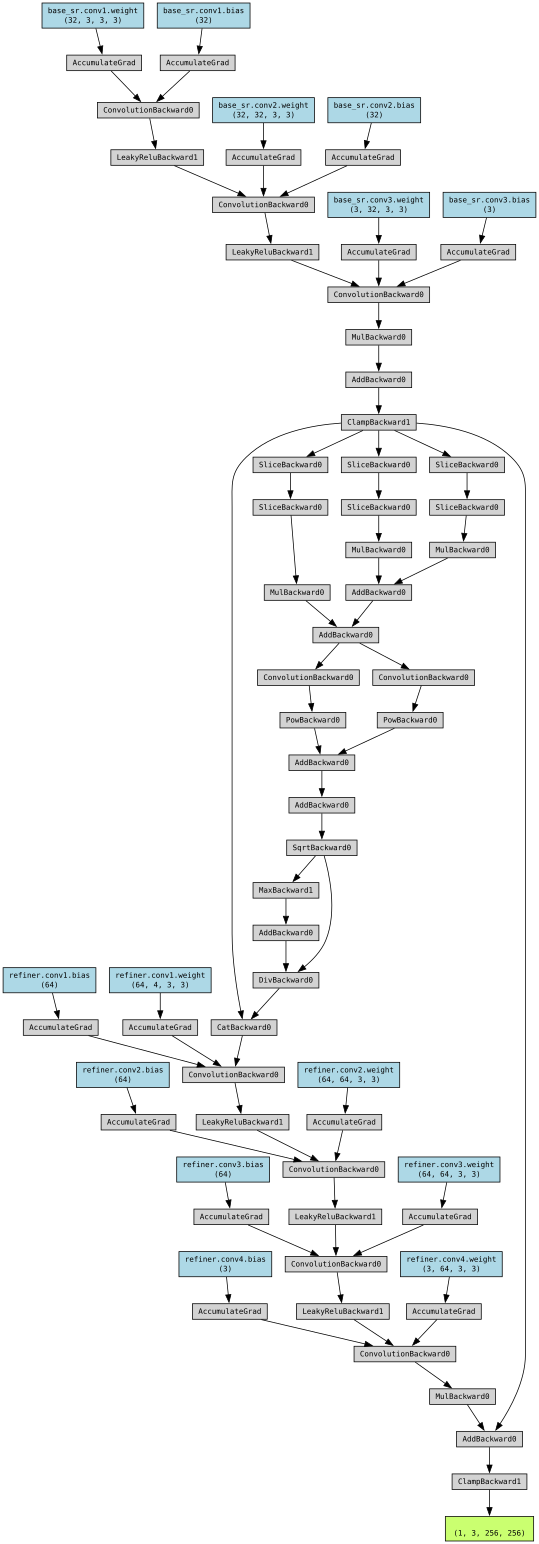

In [11]:
# =====================================================
# Torchviz graph for HighQualityHybridSRModel
# =====================================================

# If torchviz is not installed, uncomment this line once:
# !pip install torchviz

import torch
from torchviz import make_dot

# 1) Instantiate the model (reuse same config you train/evaluate with)
base_sr = ImprovedSRModel(scale=4, base_channels=32)
refiner = EnhancedRefiner(base_channels=64)
hq_model = HighQualityHybridSRModel(base_sr, refiner, max_total_time=120.0)

# 2) Create a dummy input (B, C, H, W)
dummy_input = torch.randn(1, 3, 64, 64)

# 3) Forward pass to get an actual tensor for graphing
hybrid_out, base_out = hq_model(dummy_input)   # hybrid_out: (1, 3, H*, W*)

# 4) Build the computational graph with torchviz
dot = make_dot(hybrid_out, params=dict(hq_model.named_parameters()))

# Optional: save as PNG file
dot.format = "png"
dot.render("HighQualityHybridSRModel_Architecture", cleanup=True)

# 5) Display inline in Jupyter (SVG-style)
dot
